In [29]:
from data import SQGData, SQGTrajData

sqg = SQGData()
noise0 = sqg.get_field()
print(noise0.shape)



new_data = SQGTrajData()
trajs = new_data.get_all()
trajs.shape

✅ SQG 数据加载完成: shape = (1001, 2, 64, 64), data_std = 2660.0
(1001, 64, 64)
------------------------------------------------------
 SQG Trajectory Dataset Loaded
  trajectories = 100
  time steps   = 101
  levels       = 2
  spatial grid = 64 × 64
  shape        = (100, 101, 2, 64, 64)
------------------------------------------------------


(100, 101, 2, 64, 64)

% Random orthonormal subspace generation process
Given a dimension $D$ and subspace dimension $k$, we generate a random Gaussian matrix:
$G \in \mathbb{R}^{D \times k}, \qquad
G_{ij} \sim \mathcal{N}(0,1).
$

Next, apply the QR decomposition to obtain an orthonormal basis:
$
G = QR,
$
where
$
Q \in \mathbb{R}^{D \times k}, \qquad R \in \mathbb{R}^{k \times k}.
$

The matrix $Q$ has orthonormal columns, i.e.,
$
Q^\top Q = I_k.
$

We then extract the first $k$ columns of $Q$ (this is redundant if $Q$ is already $D \times k$):
$
Q_{\text{sub}} = Q_{[:, 1:k]}.
$

Therefore, $Q_{\text{sub}}$ represents a random point on the Stiefel manifold:
$
Q_{\text{sub}} \in \mathrm{St}(D, k),
$
that is, the space of all $D \times k$ real matrices with orthonormal columns.


# 证明线性Or非线性correlation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d
from scipy.ndimage import gaussian_filter

def _detrend_and_standardize(frames, local=False, local_sigma=0):
    """
    对帧序列去趋势并标准化。
    frames: (K, X, Y)
    local=False: 仅全局去均值、全局标准差
    local=True: 先用高斯滤波提取趋势(均值场)，再除以局部标准差（更严格）
    """
    K, X, Y = frames.shape
    F = frames.astype(np.float64)
    if not local:
        F = F - F.mean()
        std = F.std()
        if std > 0:
            F = F / std
        return F
    else:
        # 局部均值/方差（用高斯平滑做缓慢变化项）
        if local_sigma <= 0:
            local_sigma = max(3, min(X, Y)//16)  # 一个比较稳的缺省
        mu = np.stack([gaussian_filter(F[k], sigma=local_sigma) for k in range(K)], axis=0)
        R = F - mu
        # 局部标准差：先局部二阶矩，再减去mu^2
        m2 = np.stack([gaussian_filter(R[k]**2, sigma=local_sigma) for k in range(K)], axis=0)
        s = np.sqrt(np.clip(m2, 0, None))
        s[s == 0] = 1.0
        Z = R / s
        # 兜底全局标准化一次
        Z = (Z - Z.mean()) / (Z.std() + 1e-12)
        return Z

def _acf2d(img):
    """
    单帧2D自相关，wrap边界，归一化C(0,0)=1
    """
    c = correlate2d(img - img.mean(), img - img.mean(), mode='full', boundary='wrap')
    c = c / (np.max(c) + 1e-12)
    return c

def _radial_average(acf2d, r_max=None):
    H, W = acf2d.shape
    cx, cy = H//2, W//2
    y, x = np.indices(acf2d.shape)
    r = np.sqrt((y - cx)**2 + (x - cy)**2)
    if r_max is None:
        r_max = int(r.max())
    rb = r.astype(np.int32)
    radial = np.zeros(r_max+1, dtype=np.float64)
    counts = np.zeros(r_max+1, dtype=np.int64)
    np.add.at(radial, rb, acf2d)
    np.add.at(counts, rb, 1)
    counts[counts == 0] = 1
    radial = radial / counts
    return radial[:r_max+1]

def _directional_profiles(acf2d, n_angles=8, r_max=None):
    """
    取若干方向的ACF曲线：rho(r, theta_m)
    用极坐标分桶（半径整值+角度整桶），返回矩阵形状 (n_angles, r_bins)
    """
    H, W = acf2d.shape
    cy, cx = H//2, W//2
    yy, xx = np.indices(acf2d.shape)
    ry = yy - cy
    rx = xx - cx
    r = np.sqrt(ry**2 + rx**2)
    if r_max is None:
        r_max = int(r.max())
    rbin = r.astype(np.int32)
    theta = np.arctan2(ry, rx)  # [-pi, pi]
    # 仅用 0..pi（因为ACF是偶函数，对称即可），把角度映射到[0, pi)
    theta = np.mod(theta, np.pi)
    # 分桶
    ang_edges = np.linspace(0, np.pi, n_angles+1, endpoint=True)
    profiles = np.zeros((n_angles, r_max+1), dtype=np.float64)
    counts = np.zeros_like(profiles, dtype=np.int64)
    for m in range(n_angles):
        mask_ang = (theta >= ang_edges[m]) & (theta < ang_edges[m+1])
        rb = rbin[mask_ang]
        vals = acf2d[mask_ang]
        # 累加到半径桶
        np.add.at(profiles[m], rb, vals)
        np.add.at(counts[m], rb, 1)
    counts[counts == 0] = 1
    profiles = profiles / counts
    return profiles[:, :r_max+1]  # (n_angles, R)

def _subblocks_indices(X, Y, blocks=(2,2)):
    bx, by = blocks
    xs = np.linspace(0, X, bx+1, dtype=int)
    ys = np.linspace(0, Y, by+1, dtype=int)
    regions = []
    for i in range(bx):
        for j in range(by):
            regions.append((slice(xs[i], xs[i+1]), slice(ys[j], ys[j+1])))
    return regions

def _wss_block_diagnostics(frames, blocks=(2,2), acf_r0=8):
    """
    分块均值/方差 + 分块ACF一致性指标 Δ_{kℓ}
    返回：
      mu_k, std_k, ratio_std, delta_median
    """
    # 用第一帧（或平均帧）做空间统计更稳定
    F = frames.mean(axis=0)  # (X, Y)
    X, Y = F.shape
    regions = _subblocks_indices(X, Y, blocks=blocks)
    mus, stds = [], []
    acfs = []
    for slx, sly in regions:
        B = F[slx, sly]
        mus.append(B.mean())
        stds.append(B.std() + 1e-12)
        ac = _acf2d(B)
        # 取小滞后窗口内的acf向量作为“形状特征”
        H, W = ac.shape
        cy, cx = H//2, W//2
        yy, xx = np.indices(ac.shape)
        r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
        mask = (r <= acf_r0)
        acfs.append(ac[mask].ravel())
    mus = np.array(mus)
    stds = np.array(stds)
    ratio_std = stds.max() / stds.min()
    # ACF形状一致性：两两欧氏距离的平方平均
    acf_mat = np.vstack(acfs)
    K = acf_mat.shape[0]
    deltas = []
    for i in range(K):
        for j in range(i+1, K):
            # 归一化后比较形状
            ai = acf_mat[i]
            aj = acf_mat[j]
            ai = (ai - ai.mean()) / (ai.std() + 1e-12)
            aj = (aj - aj.mean()) / (aj.std() + 1e-12)
            d = np.mean((ai - aj)**2)
            deltas.append(d)
    delta_median = np.median(deltas) if deltas else 0.0
    return mus, stds, ratio_std, delta_median

def _spectrum_and_kappa(frames, smooth_sigma=1.5):
    """
    频域周期图 + 结构张量特征值比 kappa
    用平均帧的FFT估计谱，作轻度高斯平滑后计算二阶矩矩阵M
    """
    F = frames.mean(axis=0)
    F = F - F.mean()
    S = np.abs(np.fft.fftshift(np.fft.fft2(F)))**2  # 周期图
    if smooth_sigma is not None and smooth_sigma > 0:
        Ssm = gaussian_filter(S, sigma=smooth_sigma)
    else:
        Ssm = S
    X, Y = Ssm.shape
    # 频率坐标（单位化到 [-1,1]）
    fy = np.linspace(-1, 1, X)
    fx = np.linspace(-1, 1, Y)
    FY, FX = np.meshgrid(fy, fx, indexing='ij')
    # 结构张量
    Mxx = np.sum((FX**2) * Ssm)
    Myy = np.sum((FY**2) * Ssm)
    Mxy = np.sum((FX*FY) * Ssm)
    M = np.array([[Mxx, Mxy], [Mxy, Myy]], dtype=np.float64)
    evals = np.linalg.eigvalsh(M)
    evals = np.sort(evals)
    lam_min, lam_max = evals[0], evals[-1]
    kappa = (lam_max / (lam_min + 1e-12))
    return S, Ssm, kappa

def spatial_correlation_diagnostics(field,
                                    average_frames=10,
                                    blocks=(2,2),
                                    n_angles=8,
                                    r_max=None,
                                    use_local_standardize=False,
                                    show_plots=True,
                                    thresholds=dict(
                                        mu_abs_max=0.1,      # |μ_k| ≤ 0.1
                                        std_ratio_max=1.5,   # max std / min std ≤ 1.5
                                        delta_median_max=0.05,# 分块ACF形状差异
                                        D_median_max=0.02,   # 方向性ACF离散度
                                        kappa_max=1.3        # 结构张量特征值比
                                    )):
    """
    基于 2D ACF + 径向平均 的“诊断—决策”实现（第一版核心）。
    输入
    ----
    field: (T, X, Y)
    average_frames: 取前K帧做平均与ACF，避免偶然噪声
    blocks: 分块个数( bx, by )
    n_angles: 方向性ACF的方向数
    r_max: 径向最大半径（None为自动）
    use_local_standardize: 是否使用局部趋势/尺度去除（更严格）
    show_plots: 是否绘图
    thresholds: 各诊断阈值（工程阈值，可在你的数据上微调）

    返回
    ----
    results: dict，含诊断指标、2D ACF、径向曲线、方向性曲线、谱图与决策结论
    """
    T, X, Y = field.shape
    K = min(average_frames, T)
    frames0 = field[:K].astype(np.float64)

    # 0) 去趋势与标准化
    frames = _detrend_and_standardize(frames0, local=use_local_standardize)

    # 1) WSS：分块均值/方差 + 2) 分块ACF形状一致性
    mu_k, std_k, std_ratio, delta_median = _wss_block_diagnostics(frames, blocks=blocks, acf_r0=8)

    # 3) 计算平均2D ACF与径向平均
    acf2d = np.zeros((2*X-1, 2*Y-1), dtype=np.float64)
    for i in range(K):
        acf2d += _acf2d(frames[i])
    acf2d /= K
    radial = _radial_average(acf2d, r_max=r_max)
    # 相关长度（1/e）
    corr_len = int(np.argmax(radial < np.exp(-1))) if np.any(radial < np.exp(-1)) else None

    # 3) 各向同性：方向性ACF离散度
    dir_profiles = _directional_profiles(acf2d, n_angles=n_angles, r_max=(len(radial)-1))
    # 只在“有效半径”（样本对足够多）评估；这里简化为前 1/3~1/2 的半径
    R = dir_profiles.shape[1]
    r_lo, r_hi = max(1, R//12), max(2, R//2)
    D_r = np.var(dir_profiles[:, r_lo:r_hi], axis=0)  # 每个半径桶的方向方差
    D_median = float(np.median(D_r))

    # 4) 频域：周期图 + 结构张量特征值比 kappa
    S, Ssm, kappa = _spectrum_and_kappa(frames, smooth_sigma=1.5)

    # 5) 决策：是否可把“径向平均”作为主要摘要
    th = thresholds
    wss_ok = (np.max(np.abs(mu_k)) <= th['mu_abs_max']) and (std_ratio <= th['std_ratio_max']) and (delta_median <= th['delta_median_max'])
    iso_ok = (D_median <= th['D_median_max']) and (kappa <= th['kappa_max'])

    if wss_ok and iso_ok:
        decision = "ACCEPT_RADIAL"  # 采用径向平均作为主要摘要
        note = ("诊断显示近似WSS与近似各向同性成立（分块均值/方差稳定、分块ACF形状一致、方向性离散度低、谱近似圆对称）。"
                "因此后续可使用径向平均ACF作为主要结果与拟合依据。")
    elif wss_ok and not iso_ok:
        decision = "KEEP_DIRECTIONAL"
        note = ("二阶平稳近似成立，但存在各向异性（方向性ACF离散度或谱椭圆率较高）。"
                "不应做径向平均作为推断依据，应保留方向族 ρ(r,θ) 或采用各向异性核建模。")
    elif (not wss_ok) and iso_ok:
        decision = "LOCAL_ANALYSIS"
        note = ("存在非平稳性（分块统计或分块ACF差异明显），尽管各向同性近似尚可。"
                "建议去趋势/局部标准化后做**局部**ACF/谱分析，或报告不同区域的径向曲线。")
    else:
        decision = "DIRECTIONAL_AND_LOCAL"
        note = ("同时存在非平稳与各向异性。径向平均仅作可视化参考，不用于推断；"
                "正文呈现方向性+局部结果，建模采用各向异性与局部平稳方法。")

    results = dict(
        # 你原函数的输出
        acf2d=acf2d,
        radial_correlation=radial,
        correlation_length=corr_len,
        # 新增诊断指标
        block_means=mu_k, 
        block_stds=std_k, 
        std_ratio=float(std_ratio),
        block_acf_shape_delta_median=float(delta_median),
        directional_profiles=dir_profiles,       # 形状 (n_angles, R)
        directional_dispersion_by_r=D_r,         # 每个半径的方向方差
        directional_dispersion_median=float(D_median),
        periodogram=S, periodogram_smooth=Ssm,
        kappa=float(kappa),
        # 决策
        decision=decision,
        decision_note=note,
        thresholds=thresholds,
        meta=dict(
            average_frames=K, blocks=blocks, n_angles=n_angles, r_range=(r_lo, r_hi),
            use_local_standardize=use_local_standardize
        )
    )

    if show_plots:
        # Only keep directional ACFs, smoothed spectrum, and WSS stats
        fig, axs = plt.subplots(1, 3, figsize=(14, 4))

        # Directional profiles (r in [r_lo, r_hi))
        for m in range(dir_profiles.shape[0]):
            axs[0].plot(np.arange(r_lo, r_hi), dir_profiles[m, r_lo:r_hi], alpha=0.8)
        axs[0].set_title(f" ACFs (n={n_angles})")
        axs[0].set_xlabel("r (px)")
        axs[0].set_ylabel("C(r)")

        # Smoothed spectrum
        im2 = axs[1].imshow(np.log1p(Ssm), cmap='magma', origin='lower')
        axs[1].set_title(f"Smoothed Spectrum (κ={results['kappa']:.2f})")
        plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)

        # WSS block stats
        axs[2].bar(np.arange(len(mu_k))-0.2, mu_k, width=0.4, label='μ_k')
        axs[2].bar(np.arange(len(mu_k))+0.2, std_k, width=0.4, label='σ_k')
        axs[2].set_title(f"WSS blocks: std_ratio={std_ratio:.2f}, Δ_med={delta_median:.3f}")
        axs[2].legend()

        plt.tight_layout()
        plt.show()

        print("【决策】", decision)
        print("说明：", note)

    return results


In [38]:
import numpy as np

def calibrate_thresholds(
    n_rep=200,
    average_frames=10,
    H=64, W=64,
    blocks=(2, 2),
    n_angles=8,
    q=0.95,
    seed=0,
):
    rng = np.random.default_rng(seed)

    # preallocate
    max_mu = np.empty(n_rep)
    std_ratio = np.empty(n_rep)
    delta_med = np.empty(n_rep)
    D_med = np.empty(n_rep)
    kappa = np.empty(n_rep)

    for i in range(n_rep):
        # only generate what you use
        white_noise = rng.standard_normal((average_frames, H, W))

        baseline = spatial_correlation_diagnostics(
            white_noise,
            average_frames=average_frames,  # function will average these frames
            blocks=blocks,
            n_angles=n_angles,
            r_max=None,
            show_plots=False
        )

        max_mu[i] = np.max(np.abs(baseline["block_means"]))
        std_ratio[i] = baseline["std_ratio"]
        delta_med[i] = baseline["block_acf_shape_delta_median"]
        D_med[i] = baseline["directional_dispersion_median"]
        kappa[i] = baseline["kappa"]

    thresholds = {
        "mu_abs_max": np.quantile(max_mu, q),
        "std_ratio_max": np.quantile(std_ratio, q),
        "delta_median_max": np.quantile(delta_med, q),
        "D_median_max": np.quantile(D_med, q),
        "kappa_max": np.quantile(kappa, q),
    }
    return thresholds

thresholds = calibrate_thresholds(n_rep=100, q=0.99, seed=42)
print(thresholds)


KeyboardInterrupt: 

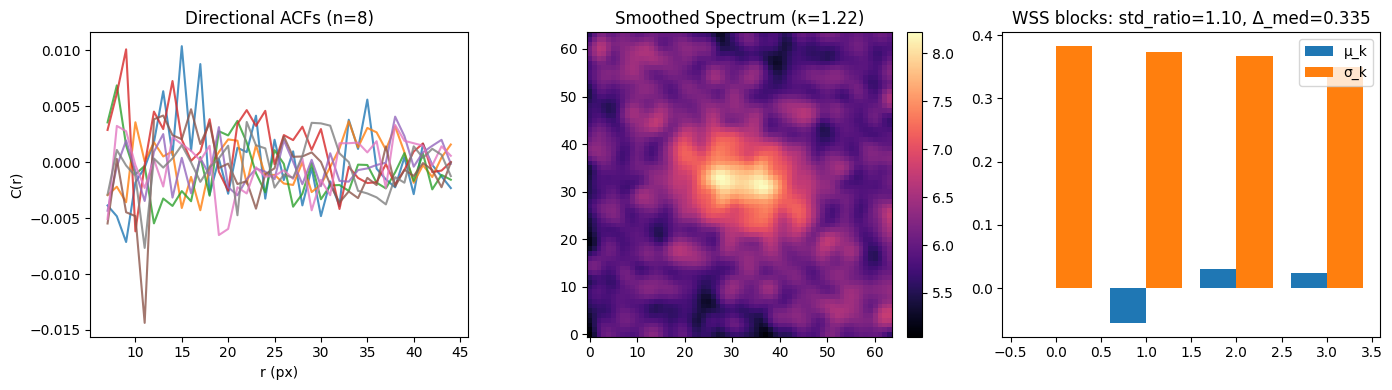

【决策】 DIRECTIONAL_AND_LOCAL
说明： 同时存在非平稳与各向异性。径向平均仅作可视化参考，不用于推断；正文呈现方向性+局部结果，建模采用各向异性与局部平稳方法。
[ 0.00049304 -0.05515296  0.03078133  0.0238786 ]
1.0955614447412874
0.3349017816209645
5.943940524900791e-06
1.2186198069899496


In [45]:
results = spatial_correlation_diagnostics(noise0, 
                                          average_frames=10, 
                                          blocks=(2,2), 
                                          n_angles=8, 
                                          r_max=None, 
                                          show_plots=True,
                                          thresholds=thresholds)
print(results['block_means'])
print(results['std_ratio'])
print(results['block_acf_shape_delta_median'])
print(results['directional_dispersion_median'])
print(results['kappa'])

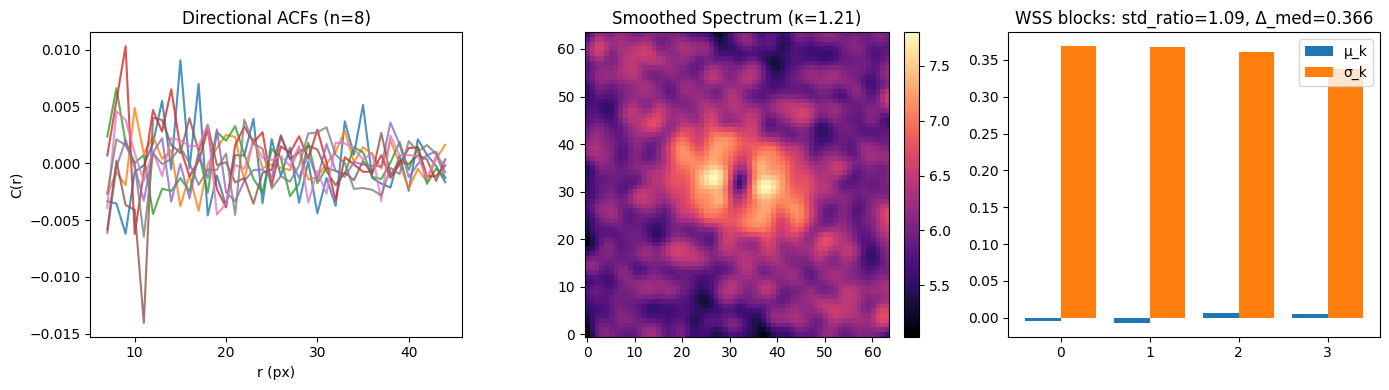

【决策】 KEEP_DIRECTIONAL
说明： 二阶平稳近似成立，但存在各向异性（方向性ACF离散度或谱椭圆率较高）。不应做径向平均作为推断依据，应保留方向族 ρ(r,θ) 或采用各向异性核建模。
[-0.00414494 -0.00690421  0.00653157  0.00451757]
1.0913247398017685
0.3657161465375189
3.7633351881873114e-06
1.212215286147137


In [46]:
results_local = spatial_correlation_diagnostics(noise0,
    average_frames=10,
    use_local_standardize=True,
    show_plots=True,
    thresholds=thresholds
)

print(results_local['block_means'])
print(results_local['std_ratio'])
print(results_local['block_acf_shape_delta_median'])
print(results_local['directional_dispersion_median'])
print(results_local['kappa'])

In [ ]:
# Improved temporal correlation diagnostics with normalized distance and block-bootstrap CIs
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List, Optional

def rolling_mean_1d(arr: np.ndarray, window: int) -> np.ndarray:
    """Centered moving average with reflect padding."""
    if window <= 1:
        return arr.astype(np.float64, copy=True)
    w = int(window)
    if w % 2 == 0:
        w += 1
    pad = w // 2
    arr = np.asarray(arr, dtype=np.float64)
    padv = np.pad(arr, (pad, pad), mode="reflect")
    ker = np.ones(w, dtype=float) / w
    out = np.convolve(padv, ker, mode="valid")
    return out

def acf_1d(x: np.ndarray, max_lag: int) -> np.ndarray:
    """Biased ACF normalized to 1 at lag 0. Returns shape (max_lag+1,)"""
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean()
    var = np.dot(x, x) / len(x)
    if var <= 0 or len(x) == 0:
        return np.zeros(max_lag + 1, dtype=np.float64)
    ac = np.correlate(x, x, mode="full")
    mid = len(ac) // 2
    ac = ac[mid: mid + max_lag + 1] / (len(x) * var)
    return ac

def block_slices(X: int, Y: int, blocks: Tuple[int, int]) -> List[Tuple[slice, slice]]:
    bx, by = blocks
    xs = np.linspace(0, X, bx + 1, dtype=int)
    ys = np.linspace(0, Y, by + 1, dtype=int)
    regions = []
    for i in range(bx):
        for j in range(by):
            regions.append((slice(xs[i], xs[i+1]), slice(ys[j], ys[j+1])))
    return regions

def _circular_block_bootstrap_1d(y: np.ndarray, L: int, B: int) -> np.ndarray:
    """Return bootstrap resamples as a 2D array (B, T) using circular block bootstrap.
    y shape: (T,)
    """
    y = np.asarray(y, dtype=np.float64)
    T = len(y)
    if T == 0:
        return np.empty((B, 0), dtype=np.float64)
    if L <= 1:
        # ordinary bootstrap on indices (less ideal for time series but fallback)
        idx = np.random.randint(0, T, size=(B, T))
        return y[idx]
    # wrap for circular indexing
    y_wrap = np.concatenate([y, y[:L-1]])
    n_blocks = int(np.ceil(T / L))
    out = np.empty((B, T), dtype=np.float64)
    for b in range(B):
        pieces = []
        for _ in range(n_blocks):
            start = np.random.randint(0, T)  # start anywhere
            pieces.append(y_wrap[start:start+L])
        boot = np.concatenate(pieces)[:T]
        out[b] = boot
    return out

def _pairwise_acf_similarity(acf_blocks: np.ndarray, drop_lag0: bool=True) -> Tuple[np.ndarray, np.ndarray]:
    """Compute pairwise shape distances/correlations between block ACF curves.
    Distance is 1 - Pearson correlation on centered ACF vectors (scale-invariant).
    Returns:
      dists: 1 - corr per pair
      cors: Pearson correlation per pair
    """
    B, L = acf_blocks.shape
    start = 1 if drop_lag0 else 0
    curves = acf_blocks[:, start:]
    # center each curve to remove scale/offset
    curves = curves - curves.mean(axis=1, keepdims=True)
    # compute pairwise correlations
    idx_i, idx_j = np.triu_indices(B, k=1)
    dists = []
    cors = []
    for i, j in zip(idx_i, idx_j):
        a = curves[i]; b = curves[j]
        denom = np.sqrt(np.dot(a,a) * np.dot(b,b)) + 1e-12
        c = float(np.dot(a,b) / denom)
        cors.append(c)
        # 1-corr忽略时间相关强度
        dists.append(1.0 - c)
    return np.array(dists, dtype=np.float64), np.array(cors, dtype=np.float64)


def _circular_block_indices(T: int, L: int) -> np.ndarray:
    if L <= 1:
        return np.random.randint(0, T, size=T)
    y_idx = np.arange(T)
    wrap = np.concatenate([y_idx, y_idx[:L-1]])
    n_blocks = int(np.ceil(T / L))
    blocks = []
    for _ in range(n_blocks):
        start = np.random.randint(0, T)
        blocks.append(wrap[start:start+L])
    idx = np.concatenate(blocks)[:T]
    return idx

def _default_block_len(T: int, acf_global: np.ndarray) -> int:

    # Integrated autocorrelation time (positive tail)
    vals = acf_global[1:]
    pos = vals[vals>0]
    iat = 1.0 + 2.0 * np.sum(pos) if pos.size>0 else 1.0
    L_iat = int(round(iat))
    L_cube = int(round(T**(1/3)))  # Politis-White heuristic scale
    L = max(8, min(64, max(L_iat, L_cube)))  # clamp to [8, 64]
    return L



In [33]:
def temporal_stationarity_diagnostics(
    field: np.ndarray,
    max_lag: int = 50,
    blocks: Tuple[int, int] = (2, 2),
    thresholds: Optional[Dict[str, float]] = None,
    # Bootstrap options
    do_bootstrap: bool = True,
    B: int = 1000,
    block_len: Optional[int] = None,
    ci_level: float = 0.95,
) -> Dict[str, object]:
    """
    Diagnose temporal WSS (Wide-Sense Stationarity) and homogeneity of temporal correlation across subspaces.
    Uses:
      - A1: stability of frame-wise spatial mean/variance over time
      - A2: homogeneity of temporal ACF (Autocorrelation Function) shape across blocks
      - Circular block bootstrap CIs for A2 summary metrics (median pairwise ACF-shape corr/dist)

    Key change vs naive approach:
      - Use energy-series (second-order) per block and globally to avoid sign cancellation in spatial means.
      - If do_bootstrap=True, A2 decision is based on bootstrap CI (confidence interval), not just point thresholds.
    """
    if thresholds is None:
        thresholds = dict(
            # A1 (heuristic tolerances). These are practical cutoffs, not universal statistical constants.
            mu_cv_max=0.1,
            sigma_ratio_max=1.5,
            # A2 (shape homogeneity tolerances)
            # dist = 1 - corr, so dist<=0.15 roughly implies corr>=0.85
            acf_dist_median_max=0.15,
            acf_corr_median_min=0.85,
        )

    assert field.ndim == 3, "`field` must be (T, X, Y)"
    T, X, Y = field.shape
    F = field.astype(np.float64, copy=False)

    # ---------------- A1: mean/variance stability ----------------
    mu_t = F.mean(axis=(1, 2))
    sigma_t = F.std(axis=(1, 2)) + 1e-12
    mu_cv = float(np.std(mu_t) / (np.std(F) + 1e-12))
    sigma_ratio = float(np.max(sigma_t) / max(np.min(sigma_t), 1e-12))

    th = thresholds
    A1_ok = (mu_cv <= th["mu_cv_max"]) and (sigma_ratio <= th["sigma_ratio_max"])

    # ---------------- Global series for visualization ----------------
    # Use global "energy series" to avoid sign cancellation of spatial mean.
    mu_g = F.mean(axis=0, keepdims=True)                      # (1, X, Y) time-mean field
    global_series = ((F - mu_g) ** 2).mean(axis=(1, 2))       # (T,) per-frame average energy
    acf_global = acf_1d(global_series, max_lag=max_lag)

    # ---------------- A2: block-wise ACFs ----------------
    regs = block_slices(X, Y, blocks)
    acf_blocks = []
    series_blocks = []  # keep for bootstrap

    for sx, sy in regs:
        block_field = F[:, sx, sy]                              # (T, bx, by)
        block_mu = block_field.mean(axis=0, keepdims=True)      # (1, bx, by) time-mean field
        block_series = ((block_field - block_mu) ** 2).mean(axis=(1, 2))  # (T,)
        series_blocks.append(block_series)
        acf_blocks.append(acf_1d(block_series, max_lag=max_lag))

    acf_blocks = np.stack(acf_blocks, axis=0)  # (n_blocks, max_lag+1)
    n_blocks = acf_blocks.shape[0]

    # normalized, scale-invariant distance: 1 - corr on centered curves
    dists, cors = _pairwise_acf_similarity(acf_blocks, drop_lag0=True)
    dist_median = float(np.median(dists)) if dists.size else 0.0
    corr_median = float(np.median(cors)) if cors.size else 1.0

    # We'll decide A2 using either point estimate (no bootstrap) or CI (with bootstrap)
    A2_ok_point = (dist_median <= th["acf_dist_median_max"]) and (corr_median >= th["acf_corr_median_min"])

    # ---------------- Bootstrap CIs for A2 summaries ----------------
    ci = {}
    A2_status = "POINT_ONLY"  # will become PASS/FAIL/INCONCLUSIVE if do_bootstrap
    A2_ok = bool(A2_ok_point)

    if do_bootstrap:
        # choose block length conservatively
        Lb = _default_block_len(T, acf_global) if block_len is None else int(block_len)

        Bboot = int(B)
        dist_samples = np.empty(Bboot, dtype=np.float64)
        corr_samples = np.empty(Bboot, dtype=np.float64)

        # synchronized circular block bootstrap: same time indices for all subspaces
        for b in range(Bboot):
            idx = _circular_block_indices(T, Lb)
            boot_acfs = []
            for s in series_blocks:
                yb = s[idx]
                boot_acfs.append(acf_1d(yb, max_lag=max_lag))
            boot_acfs = np.stack(boot_acfs, axis=0)
            d_b, c_b = _pairwise_acf_similarity(boot_acfs, drop_lag0=True)
            dist_samples[b] = np.median(d_b) if d_b.size else 0.0
            corr_samples[b] = np.median(c_b) if c_b.size else 1.0

        alpha = 1.0 - float(ci_level)
        lo = 100 * alpha / 2.0
        hi = 100 * (1.0 - alpha / 2.0)

        dist_ci = (float(np.percentile(dist_samples, lo)),
                   float(np.percentile(dist_samples, hi)))
        corr_ci = (float(np.percentile(corr_samples, lo)),
                   float(np.percentile(corr_samples, hi)))

        ci["acf_dist_median"] = dist_ci
        ci["acf_corr_median"] = corr_ci
        ci["block_len_used"] = int(Lb)
        ci["B"] = int(Bboot)
        ci["level"] = float(ci_level)

        # --- CI-based A2 decision (main improvement) ---
        dist_max = th["acf_dist_median_max"]
        corr_min = th["acf_corr_median_min"]

        dist_lo, dist_hi = dist_ci
        corr_lo, corr_hi = corr_ci

        # PASS if CI is entirely in the acceptable region
        if (dist_hi <= dist_max) and (corr_lo >= corr_min):
            A2_status = "PASS"
            A2_ok = True
        # FAIL if CI is entirely outside (strong evidence of heterogeneity)
        elif (dist_lo > dist_max) or (corr_hi < corr_min):
            A2_status = "FAIL"
            A2_ok = False
        # Otherwise: insufficient evidence either way
        else:
            A2_status = "INCONCLUSIVE"
            # keep A2_ok as point estimate for convenience, but mark status explicitly
            A2_ok = bool(A2_ok_point)

    # ---------------- Final decision (after CI if available) ----------------
    if A1_ok and A2_ok:
        decision = "GLOBAL_TEMPORAL_OK"
        note = "时间二阶平稳且子空间间的时间相关形状一致；可用全局共享的时间模型。"
    elif A1_ok and not A2_ok:
        decision = "LOCAL_TEMPORAL_ONLY"
        note = "时间近似平稳，但不同子空间的时间相关形状存在差异；建议局部时间模型或空间自适应时间核。"
    elif (not A1_ok) and A2_ok:
        decision = "DETREND_OR_VARIANCE_STABILIZE"
        note = "时间非平稳（均值/方差随 t 变动），但各子空间时间相关形状相似；需更强去趋势/稳定化。"
    else:
        decision = "NONSTATIONARY_AND_HETEROGENEOUS"
        note = "时间非平稳且子空间时间相关不一致；建议局部+分段时间建模。"

    # ---------------- Plots ----------------
    # 1) mu_t
    plt.figure()
    plt.plot(mu_t)
    plt.title("μ_t over time")
    plt.xlabel("t"); plt.ylabel("μ_t"); plt.grid(True, alpha=0.3); plt.tight_layout()

    # 2) sigma_t
    plt.figure()
    plt.plot(sigma_t)
    plt.title("σ_t over time")
    plt.xlabel("t"); plt.ylabel("σ_t"); plt.grid(True, alpha=0.3); plt.tight_layout()

    # 3) Global ACF (energy series)
    plt.figure()
    plt.plot(np.arange(len(acf_global)), acf_global, marker="o")
    plt.title("Global temporal ACF (energy series)")
    plt.xlabel("lag h"); plt.ylabel("ρ(h)"); plt.grid(True, alpha=0.3); plt.tight_layout()

    # 4) Block-wise ACFs (energy series per block)
    plt.figure()
    for k in range(n_blocks):
        plt.plot(acf_blocks[k], label=f"block {k+1}")
    plt.title("Block-wise temporal ACFs (energy series per subspace)")
    plt.xlabel("lag h"); plt.ylabel("ρ(h)"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()

    metrics = dict(
        mu_cv=float(mu_cv),
        sigma_ratio=float(sigma_ratio),
        acf_dist_median=float(dist_median),
        acf_corr_median=float(corr_median),
        A1_time_WSS_ok=bool(A1_ok),
        A2_temporal_homogeneity_ok=bool(A2_ok),
        A2_status=str(A2_status),  # PASS/FAIL/INCONCLUSIVE/POINT_ONLY
        decision=str(decision),
        note=str(note),
        thresholds=thresholds,
    )

    out = dict(
        mu_t=mu_t,
        sigma_t=sigma_t,
        global_series=global_series,
        acf_global=acf_global,
        acf_blocks=acf_blocks,
        metrics=metrics,
    )
    if do_bootstrap:
        out["bootstrap"] = ci
    return out


{'mu_cv': 0.004668730403162819, 'sigma_ratio': 1.1008523090309106, 'acf_dist_median': 0.0633746318623894, 'acf_corr_median': 0.9366253681376107, 'A1_time_WSS_ok': True, 'A2_temporal_homogeneity_ok': True, 'A2_status': 'PASS', 'decision': 'GLOBAL_TEMPORAL_OK', 'note': '时间二阶平稳且子空间间的时间相关形状一致；可用全局共享的时间模型。', 'thresholds': {'mu_cv_max': 0.1, 'sigma_ratio_max': 1.5, 'acf_dist_median_max': 0.15, 'acf_corr_median_min': 0.85}}
{'acf_dist_median': (0.02550110396062585, 0.13387634689096425), 'acf_corr_median': (0.8661236531090357, 0.9744988960393741), 'block_len_used': 18, 'B': 1000, 'level': 0.95}


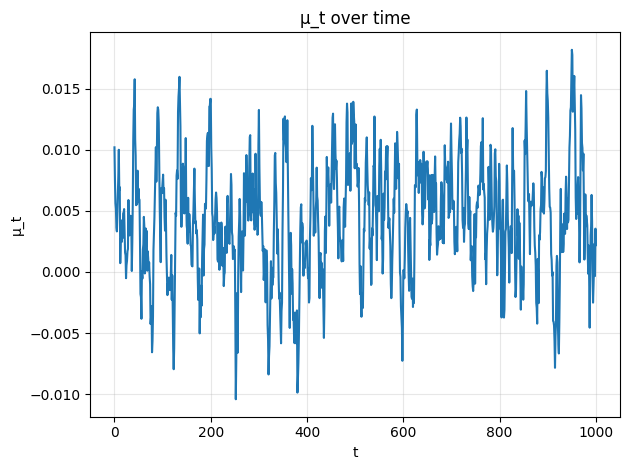

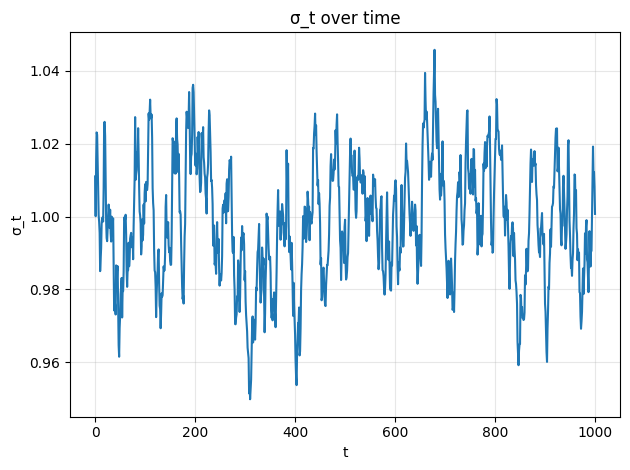

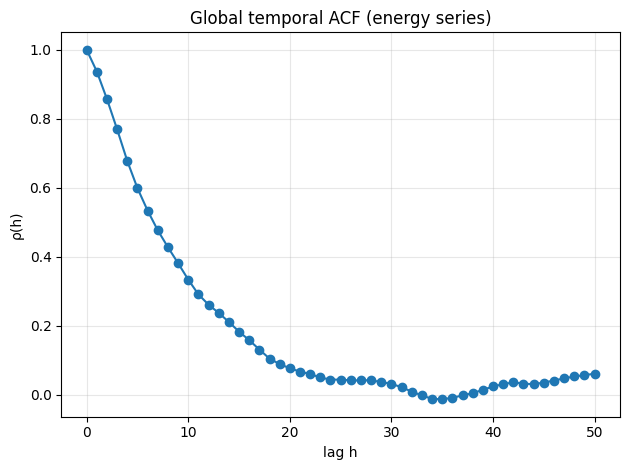

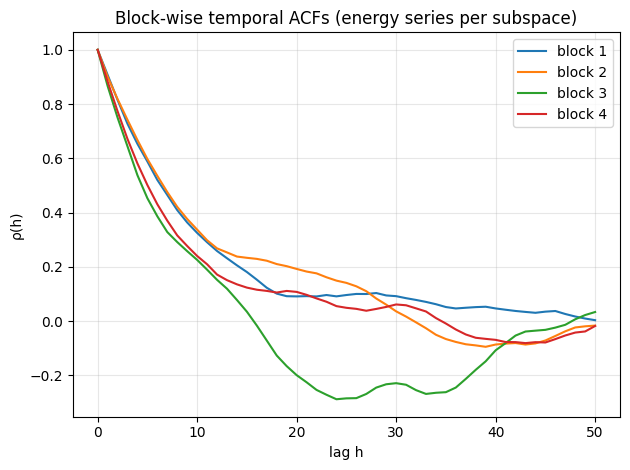

In [34]:
res = temporal_stationarity_diagnostics(
    noise0,
    max_lag=50,
    blocks=(2,2),
    # Bootstrap 相关
    do_bootstrap=True,
    B=1000,          # bootstrap 轮数
    block_len=None,  # 默认自动=IAT（积分自相关时间）的近似
    ci_level=0.95
)

print(res["metrics"])
print(res["bootstrap"])   # 里面有 acf_dist_median 与 acf_corr_median 的 CI


Project 7: Latent Dynamics for Forecasting with Generative Models Project Supervisor: Martin Andrae martin.andrae@liu.se

Flow-based generative models learn to transform simple random noise (typically from a standard normal distribution) into complex data, like images or physical states. This is done using a smooth, reversible mapping described by an ODE. By reversing this mapping, we can encode data back into a *latent space*—a simplified representation where structure may be easier to analyze.

In this project, we apply this idea to a spatiotemporal system governed by a chaotic PDE. A pre-trained generative model is used to map physical states into latents, and your task is to investigate the properties and dynamics of these latent representations. The goal is to better understand whether the latent space can support probabilistic forecasting.

Project Goals (choose one or combine):

1. Learn the latent dynamics Treat the latent trajectory as a time series. Try fitting a simple predictive model that learns how the latents evolve over time. Start with basic regression (e.g., linear or autoregressive models), and optionally explore more flexible approaches like neural networks.

2. Analyze the latent distribution Check whether the latent states follow a standard Gaussian distribution (as they ideally should). Use tools like histograms, Q-Q plots, or correlation analysis to test this. Consider both the spatial and temporal structure in the latent trajectories.

3. Explore interpolation and sampling Latent interpolations often yield meaningful transitions in physical space when decoded. Traditionally, these are done via linear interpolation, but stochastic approaches (e.g., Brownian bridges) may offer richer insights. Similarly, sampling near a known latent can generate realistic nearby states. Explore and quantify how different interpolation and sampling methods affect the decoded outputs. Note: Requires a GPU-capable laptop and some experience with PyTorch.

项目叙述或许对我们的下一步方向有帮助

我们现在有更大的数据集，我们再把我们的验证做一遍，看看是不是真的白噪声，相当于又回到了起点，今天要给他发个报告

Estimated OU a = 0.1640251
Average sigma^2: 0.97302544


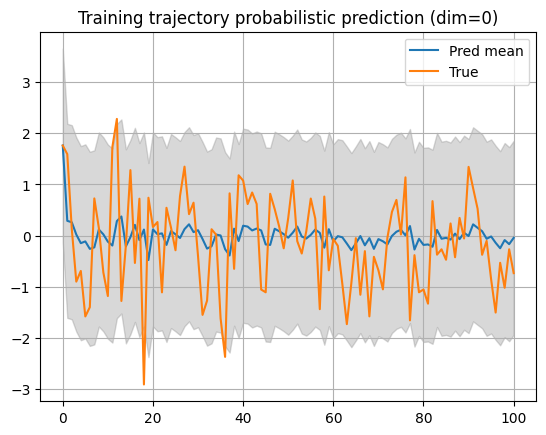

Average per-dimension 95% coverage on noise0: 0.9501142578125


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# traj shape: (100, 101, 64, 64)
N_traj, T_traj, X, Y = trajs.shape
D = X * Y

# flatten
traj_flat = trajs.reshape(N_traj, T_traj, D)

# ------------------------------------
# 1) Collect all z_t and z_{t+1}
# ------------------------------------
Z_t = []
Z_tp1 = []

for i in range(N_traj):
    Z_t.append(traj_flat[i, :-1, :])     # (100, 4096)
    Z_tp1.append(traj_flat[i, 1:, :])    # (100, 4096)

Z_t = np.concatenate(Z_t, axis=0)       # (10000, 4096)
Z_tp1 = np.concatenate(Z_tp1, axis=0)   # (10000, 4096)

# ------------------------------------
# 2) Estimate scalar OU coefficient a
# ------------------------------------
num = np.sum(Z_t * Z_tp1, axis=0)       # per-dimension numerator
den = np.sum(Z_t * Z_t, axis=0) + 1e-12 # avoid zero

a_dims = num / den                      # (4096,)
a = np.mean(a_dims)                     # scalar a
print("Estimated OU a =", a)

# ------------------------------------
# 3) Estimate diagonal noise covariance Σ
# ------------------------------------
eps = Z_tp1 - a * Z_t
sigma2 = np.mean(eps * eps, axis=0)     # (4096,)
print("Average sigma^2:", np.mean(sigma2))

# ------------------------------------
# 4) Probabilistic forecast on training
# ------------------------------------
# pick trajectory 0
z_train = traj_flat[0]    # shape (101, 4096)
z_pred_mean = []
z_pred_low = []
z_pred_high = []
z_true = []

z_t = z_train[0]

z_pred_mean.append(z_t)
z_true.append(z_t)

for t in range(100):
    mean_next = a * z_t
    z_pred_mean.append(mean_next)
    z_true.append(z_train[t+1])
    z_t = z_train[t+1]

# visualize 1 dimension (e.g. dim 0)
dim = 0
sigma = np.sqrt(sigma2[dim])

mu = np.array([m[dim] for m in z_pred_mean])
tru = np.array([t_[dim] for t_ in z_true])
low = mu - 1.96 * sigma
high = mu + 1.96 * sigma

plt.figure()
plt.plot(mu, label="Pred mean")
plt.plot(tru, label="True")
plt.fill_between(range(len(mu)), low, high, color='gray', alpha=0.3)
plt.title("Training trajectory probabilistic prediction (dim=0)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------
# 5) Apply to new data noise0
# ------------------------------------
noise_flat = noise0.reshape(noise0.shape[0], D)
coverage = 0
count = 0
true_vals = noise_flat

for t in range(noise_flat.shape[0] - 1):
    mean_next = a * noise_flat[t]
    diff = true_vals[t+1] - mean_next
    ci_low = mean_next - 1.96 * np.sqrt(sigma2)
    ci_high = mean_next + 1.96 * np.sqrt(sigma2)

    inside = (true_vals[t+1] >= ci_low) & (true_vals[t+1] <= ci_high)
    coverage += np.mean(inside)
    count += 1

print("Average per-dimension 95% coverage on noise0:", coverage / count)


In [4]:
sigma2.shape

(4096,)

Estimated OU a (per-dimension) stats: mean= 0.16402509808540344 min= 0.11435957252979279 max= 0.22012269496917725
sigma^2 mean: 0.9727766513824463


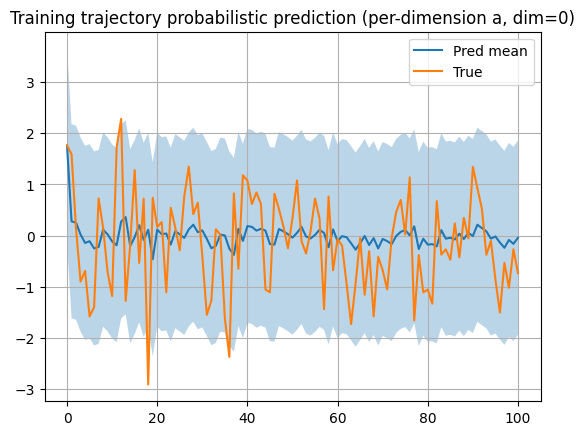

Average per-dimension 95% coverage on noise0 (per-column a): 0.95002294921875


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# 2) Estimate per-dimension OU coefficient a_vec (column-wise)
#     a_j = sum_t z_tj * z_{t+1,j} / sum_t z_tj^2
# ------------------------------------
num = np.sum(Z_t * Z_tp1, axis=0)              # (D,)
den = np.sum(Z_t * Z_t,   axis=0) + 1e-12      # avoid zero
a_vec = num / den                               # (D,)
print("Estimated OU a (per-dimension) stats:",
      "mean=", float(np.mean(a_vec)), "min=", float(np.min(a_vec)), "max=", float(np.max(a_vec)))

# ------------------------------------
# 3) Estimate per-dimension noise variance sigma^2 (diagonal)
#     epsilon_tj = z_{t+1,j} - a_j * z_{t,j}
# ------------------------------------
eps = Z_tp1 - Z_t * a_vec[None, :]             # broadcast (N*(T-1), D)
sigma2 = np.mean(eps * eps, axis=0)            # (D,)
print("sigma^2 mean:", float(np.mean(sigma2)))

# ------------------------------------
# 4) Probabilistic forecast on training trajectory 0 (dimension-wise)
#     mean_next_j = a_j * z_tj
# ------------------------------------
z_train = traj_flat[0]                # (T_traj, D)
z_pred_mean = []
z_true = []

z_t = z_train[0]                      # (D,)
z_pred_mean.append(z_t.copy())
z_true.append(z_t.copy())

for t in range(T_traj - 1):
    mean_next = a_vec * z_t           # (D,)
    z_pred_mean.append(mean_next)
    z_true.append(z_train[t+1])
    z_t = z_train[t+1]

# visualize one dimension (e.g., dim=0)
dim = 0
sigma = np.sqrt(sigma2[dim])

mu = np.array([m[dim] for m in z_pred_mean])   # (T_traj,)
tru = np.array([t_[dim] for t_ in z_true])     # (T_traj,)
low = mu - 1.96 * sigma
high = mu + 1.96 * sigma

plt.figure()
plt.plot(mu, label="Pred mean")
plt.plot(tru, label="True")
plt.fill_between(range(len(mu)), low, high, alpha=0.3)
plt.title("Training trajectory probabilistic prediction (per-dimension a, dim=0)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------
# 5) Apply to new data noise0 (shape assumed (T0, X, Y) or (T0, D) after reshape)
#     coverage of 95% CI per step averaged over dimensions
# ------------------------------------
# ensure shape (T0, D)
if noise0.ndim == 3:
    T0 = noise0.shape[0]
    noise_flat = noise0.reshape(T0, D)
else:
    noise_flat = noise0  # (T0, D)

coverage = 0.0
count = 0
true_vals = noise_flat

for t in range(noise_flat.shape[0] - 1):
    mean_next = true_vals[t] * a_vec                 # (D,)
    ci_low = mean_next - 1.96 * np.sqrt(sigma2)      # (D,)
    ci_high = mean_next + 1.96 * np.sqrt(sigma2)     # (D,)
    inside = (true_vals[t+1] >= ci_low) & (true_vals[t+1] <= ci_high)
    coverage += np.mean(inside)
    count += 1

print("Average per-dimension 95% coverage on noise0 (per-column a):", coverage / max(count, 1))


In [6]:
sigma2.shape

(4096,)

我现在要预测下一步的数据然后映射回物理空间


In [5]:
from sampler import Sampler

model_path = "best_model.pth"
image_shape = (2, 64, 64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


eps = lambda t: 0.1 * (1 - t)  # Noise when sampling
invert_eps = lambda t: 0. * (1 - t)  # Noise when inverting
members = 5
steps = 100
invert_steps = 100
debug = False

sampler = Sampler(device, members, eps, steps, invert_eps, invert_steps, model_path, debug)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def visualize_truth_invert_rollout(members=5, traj_id=0):
    """
    Plot three columns per time step:
      Col-1: Truth physics field
      Col-2: Physics decoded from TRUE latent (inverse mapping of 'noise' via sampler.sample)
      Col-3: Physics decoded from ROLLOUT latent (your OU/other dynamics), then inverse mapping

    Globals expected:
      - new_data: provides .get_traj(traj_id, dataset="truth"/"noise")
      - sampler: provides .sample(tensor) -> inverse mapping (latent -> physics)
      - device: torch device
      - a: OU 'a' coefficient (scalar or vector of size D)
      - sigma2: OU noise variance (scalar or vector broadcastable to D)
      - data_std: scaling factor to de-standardize physics (e.g., 2660)

    Args:
      members (int): rollout length and also the number of frames shown
      traj_id (int): which trajectory to fetch

    Returns:
      None (displays a figure)
    """

    # ---------------------------
    # 1) Load a short clip
    # ---------------------------
    true_phy = new_data.get_traj(traj_id=traj_id, dataset="truth")  # expected (T, C, H, W)
    noise    = new_data.get_traj(traj_id=traj_id, dataset="noise")  # expected (T, C, H, W)

    # take first `members` frames for side-by-side comparison
    true_phyN = true_phy[:members, ...]    # (members, C, H, W)
    noiseN    = noise[:members, ...]       # (members, C, H, W)

    # ---------------------------
    # 2) Invert TRUE latent to physics (column-2)
    #    We assume 'noiseN' is the latent input to sampler.sample()
    # ---------------------------
    x = torch.from_numpy(noiseN).to(torch.float32).to(device)            # (members, C, H, W)
    x_invert = sampler.sample(x).detach().cpu().numpy()                  # (members, C, H, W)

    # pick channel-0 to compare (aligns with your example) and de-standardize
    truth_phys = true_phyN[:, 0, ...]                                    # (members, H, W)
    invert_phys = x_invert[:, 0, ...] * 2660                         # (members, H, W)

    # ---------------------------
    # 3) ROLLOUT latent (column-3)  <<< ROLLOUT LOGIC HERE >>>
    #    You can swap this block with a different latent dynamics later.
    #    Current logic: simple OU AR(1) per-dimension with coeff 'a' and noise var 'sigma2'.
    # ---------------------------
    # seed from the very first latent frame's channel-0 (as your example)
    lat0 = noise[0, 0, ...]                                              # (H, W)
    H, W = lat0.shape
    x0 = lat0.flatten()                                                  # (D,)
    D = x0.shape[0]

    xs = np.zeros((members, D), dtype=np.float32)
    xs[0] = x0

    # allow scalar or vector a/sigma2; compute sigma from sigma2
    sigma = np.sqrt(sigma2)

    # ---- OU rollout (you may replace from here) ----
    # AR(1): x_{t+1} = a * x_t + N(0, sigma^2 I)
    for i in range(1, members):
        noise_term = np.random.randn(D).astype(np.float32) * sigma
        xi = a_vec * xs[i - 1] + noise_term
        xs[i] = xi
    # ---- end of ROLLOUT LOGIC ----
    
    # to 4D latent: (T, C=2, H, W) because sampler expects 2-ch like your code
    rollout_lat = xs.reshape(members, H, W)[:, None, ...]                # (T, 1, H, W)
    rollout_lat = np.concatenate([rollout_lat, np.zeros_like(rollout_lat)], axis=1)  # (T, 2, H, W)

    # inverse map rollout latent -> physics, pick channel-0 and de-standardize
    rollout_lat_t = torch.from_numpy(rollout_lat).to(torch.float32).to(device)
    rollout_phys = sampler.sample(rollout_lat_t).detach().cpu().numpy()  # (T, 2, H, W)
    rollout_phys = rollout_phys[:, 0, ...] * 2660                    # (T, H, W)

    # ---------------------------
    # 4) Sanity checks
    # ---------------------------
    assert truth_phys.shape == invert_phys.shape == rollout_phys.shape, \
        f"Shape mismatch: {truth_phys.shape}, {invert_phys.shape}, {rollout_phys.shape}"

    T = members

    # unified color scale across THREE columns
    vmin = min(truth_phys.min(), invert_phys.min(), rollout_phys.min())
    vmax = max(truth_phys.max(), invert_phys.max(), rollout_phys.max())

    # per-frame RMSE for columns 2 & 3 vs truth
    rmse_invert  = np.sqrt(((invert_phys  - truth_phys) ** 2).mean(axis=(1, 2)))   # (T,)
    rmse_rollout = np.sqrt(((rollout_phys - truth_phys) ** 2).mean(axis=(1, 2)))   # (T,)

    # ---------------------------
    # 5) Plot: T rows × 3 cols
    # ---------------------------
    def set_cbar(im):
        ax = im.axes
        cax = inset_axes(ax,
                         width="100%",
                         height="5%",
                         loc='upper center',
                         bbox_to_anchor=(0, 0.18, 1, 1),
                         bbox_transform=ax.transAxes,
                         borderpad=0)
        cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')

    fig, axs = plt.subplots(T, 3, figsize=(12, 2.2 * T), constrained_layout=True)
    axs = np.atleast_2d(axs)
    cmap = plt.get_cmap('viridis', 10)

    for t in range(T):
        # Col-1: Truth
        ax = axs[t, 0]
        ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(truth_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Truth (t={t})", fontsize=11)
        set_cbar(im)

        # Col-2: Inverted from TRUE latent
        ax = axs[t, 1]
        ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(invert_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Invert from TRUE latent (RMSE={rmse_invert[t]:.3f})", fontsize=11)
        set_cbar(im)

        # Col-3: Inverted from ROLLOUT latent
        ax = axs[t, 2]
        ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(rollout_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Rollout → Invert (RMSE={rmse_rollout[t]:.3f})", fontsize=11)
        set_cbar(im)

    plt.show()


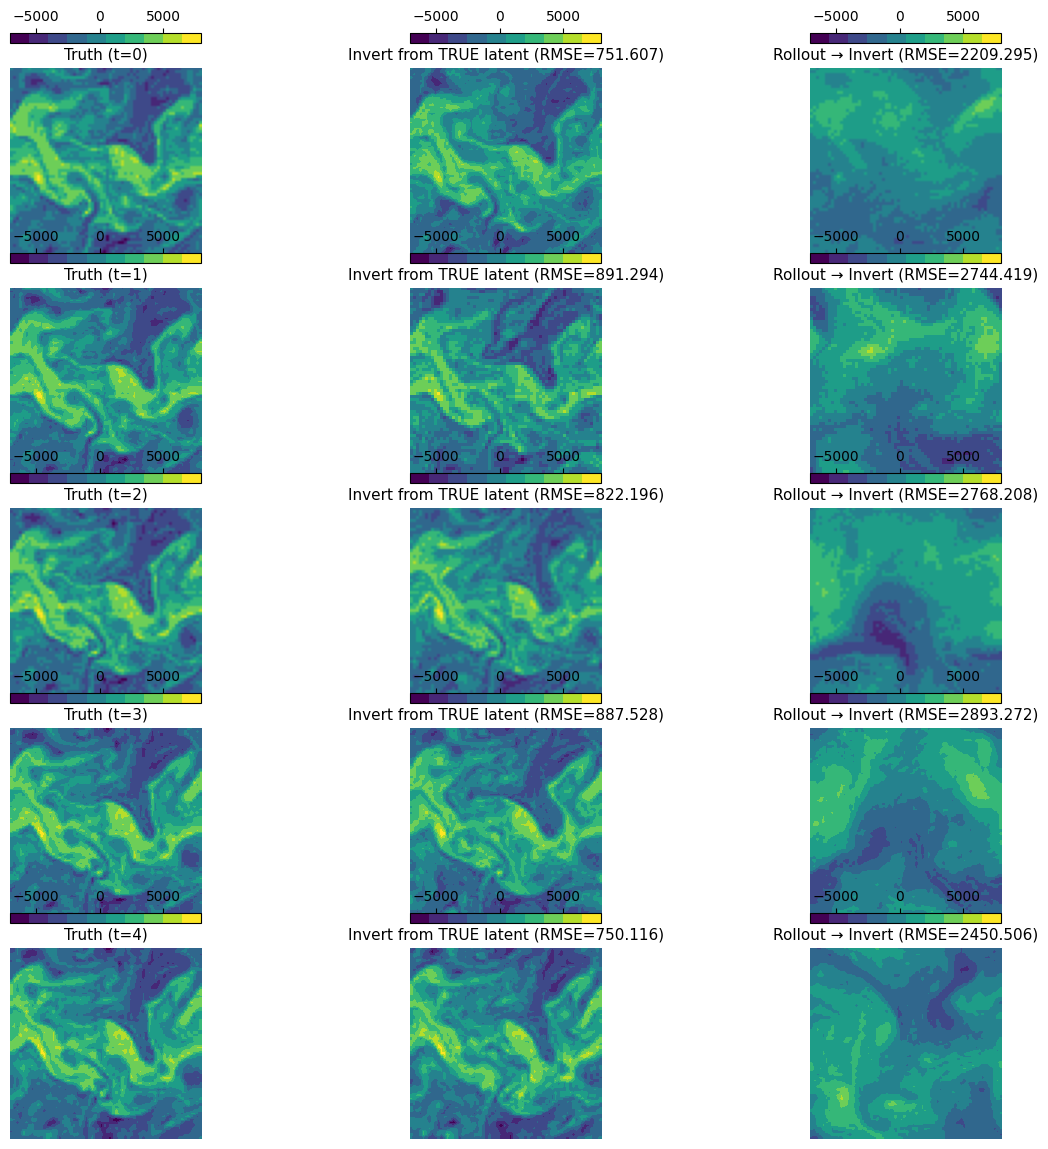

In [12]:
visualize_truth_invert_rollout(members=5, traj_id=0)

做的什么投影在取低rank的什么矩阵，相当于full A吧

In [13]:
def fit_lowrank_A_RRR(Z_t, Z_tp1, rank_r=32, ridge=1e-3):
    """
    Fit A (D x D) with rank<=r via Reduced-Rank Regression (RRR).
    Minimize ||Y - X A||_F subject to rank(A) <= r.
    
    Args:
      Z_t   : (N, D) design matrix X
      Z_tp1 : (N, D) response     Y
      rank_r: target rank
      ridge : lambda for (X^T X + lambda I)^-1 (numerical stability)
      
    Returns:
      A_rrr : (D, D) low-rank transition matrix
      info  : dict with diagnostics
    """
    X = Z_t
    Y = Z_tp1
    N, D = X.shape
    assert Y.shape == (N, D)

    # G = X^T X + lambda I
    G = X.T @ X
    if ridge > 0:
        G = G + ridge * np.eye(D)

    # Solve G^{-1} X^T Y without explicit inverse
    # A_ols^T = G^{-1} (X^T Y)  -> use solve
    XtY = X.T @ Y
    # We solve G * A_ols^T = XtY  -> A_ols^T = solve(G, XtY)
    A_ols_T = np.linalg.solve(G, XtY)
    A_ols = A_ols_T.T  # (D, D)

    # Compute C = Y^T X G^{-1} X^T Y = Y^T P_X Y (ridge version)
    # We already have B = G^{-1} X^T Y = A_ols^T
    # So X G^{-1} X^T Y = X @ (A_ols^T) = X @ A_ols_T
    XAolsT = X @ A_ols_T            # (N, D)
    C = Y.T @ XAolsT                # (D, D)

    # Eigen-decomposition of C
    # We need top-r eigenvectors (largest eigenvalues)
    evals, evecs = np.linalg.eigh(C)  # symmetric
    idx = np.argsort(evals)[::-1]     # descending
    V_r = evecs[:, idx[:rank_r]]      # (D, r)

    # Reduced-Rank solution: A_rrr = A_ols V_r V_r^T
    A_rrr = A_ols @ (V_r @ V_r.T)

    info = {
        "ridge": ridge,
        "rank_r": rank_r,
        "eigvals_top": evals[idx[:rank_r]],
        "A_ols_normF": np.linalg.norm(A_ols, "fro"),
        "A_rrr_normF": np.linalg.norm(A_rrr, "fro")
    }
    return A_rrr, info

In [19]:
rank_r  = 64        # 你可以从 16/32/64 做网格搜索
ridge   = 1e-2      # 增大一点以增强稳定性
A_lr, info = fit_lowrank_A_RRR(Z_t, Z_tp1, rank_r=rank_r, ridge=ridge)
print("RRR info:", info)

RRR info: {'ridge': 0.01, 'rank_r': 64, 'eigvals_top': array([23979.59974684, 22717.32316528, 22440.12628556, 22335.81924504,
       22197.48224801, 22134.9116436 , 21886.92484433, 21798.41711531,
       21634.09934492, 21561.49098462, 21519.7417295 , 21338.9517127 ,
       21257.31245535, 21198.40200266, 21092.68302519, 21011.75977947,
       20977.30852824, 20858.83800368, 20739.57775154, 20642.33926752,
       20628.20774166, 20564.97228237, 20534.94001739, 20480.90192511,
       20357.13931377, 20313.37289503, 20269.77732034, 20176.47525958,
       20116.55781234, 20008.51848099, 19994.9050239 , 19958.57830411,
       19934.11118605, 19851.23178954, 19819.5762648 , 19767.57700723,
       19718.23423718, 19616.08294811, 19564.05264957, 19504.92003546,
       19438.27226374, 19415.27191676, 19385.23338125, 19296.9972078 ,
       19265.13221608, 19244.73437993, 19168.78702162, 19126.71303933,
       19091.67623799, 19075.29561881, 19007.31121164, 18966.47748462,
       18957.90959273,

你得看看这个有没有改进

In [17]:
def rollout_linear_lowrank(z0, A, T_steps, sigma2=None, random_state=None):
    """
    Linear rollout: z_{t+1} = z_t A + epsilon, epsilon ~ N(0, diag(sigma2)).
    If sigma2 is None: deterministic.
    
    Args:
      z0         : (D,) initial state
      A          : (D, D) transition matrix (low-rank)
      T_steps    : int rollout length
      sigma2     : (D,) or scalar variance; if None => 0
      random_state: np.random.RandomState or None
      
    Returns:
      Z_roll : (T_steps, D)
    """
    if random_state is None:
        random_state = np.random

    D = z0.shape[0]
    Z = np.zeros((T_steps, D), dtype=np.float32)
    Z[0] = z0.astype(np.float32)

    add_noise = sigma2 is not None
    if add_noise and np.isscalar(sigma2):
        sigma = float(np.sqrt(sigma2))
    elif add_noise:
        sigma = np.sqrt(sigma2).astype(np.float32)

    for t in range(1, T_steps):
        mean_next = Z[t-1] @ A   # (D,)
        if add_noise:
            if np.isscalar(sigma2):
                eps = random_state.randn(D).astype(np.float32) * sigma
            else:
                eps = random_state.randn(D).astype(np.float32) * sigma
            Z[t] = mean_next + eps
        else:
            Z[t] = mean_next
    return Z


def visualize_truth_invert_rollout(members=5, traj_id=0):
    """
    Col-1: Truth physics
    Col-2: Physics decoded from TRUE latent
    Col-3: Physics decoded from ROLLOUT latent (low-rank linear rollout), then inverse mapping

    Globals expected:
      - new_data.get_traj(traj_id, dataset="truth"/"noise")
      - sampler.sample(tensor)  # latent -> physics
      - device
      - A_lr: low-rank transition matrix (D x D)
      - sigma2: optional noise variance for rollout (scalar or (D,))
      - data_std: de-standardization factor (e.g., 2660)
      - rollout_linear_lowrank(z0, A, T_steps, sigma2=None) -> (T_steps, D)
    """

    # ---------------------------
    # 1) Load a short clip
    # ---------------------------
    true_phy = new_data.get_traj(traj_id=traj_id, dataset="truth")  # (T, C, H, W)
    noise    = new_data.get_traj(traj_id=traj_id, dataset="noise")  # (T, C, H, W)

    # first `members` frames
    true_phyN = true_phy[:members, ...]    # (members, C, H, W)
    noiseN    = noise[:members, ...]       # (members, C, H, W)

    # ---------------------------
    # 2) Invert TRUE latent to physics (column-2)
    # ---------------------------
    x = torch.from_numpy(noiseN).to(torch.float32).to(device)            # (members, C, H, W)
    x_invert = sampler.sample(x).detach().cpu().numpy()                  # (members, C, H, W)

    # compare channel-0
    truth_phys  = true_phyN[:, 0, ...]                                   # (members, H, W)
    invert_phys = x_invert[:, 0, ...] * 2660                         # (members, H, W)

    # ---------------------------
    # 3) ROLLOUT latent via low-rank A (REPLACED BLOCK)
    #    rollout_linear_lowrank should implement:
    #    z_{t+1} = z_t @ A_lr + eps, eps~N(0, diag(sigma2)) if sigma2 provided
    # ---------------------------
    lat0 = noise[0, 0, ...]                                              # (H, W)
    H, W = lat0.shape
    D = H * W
    z0_lat = lat0.reshape(-1)                                            # (D,)

    # rollout in latent
    Z_roll = rollout_linear_lowrank(z0_lat, A=A_lr, T_steps=members, sigma2=sigma2)  # (T, D)

    # to sampler format: (T, 2, H, W)
    rollout_lat = Z_roll.reshape(members, H, W)[:, None, ...]            # (T, 1, H, W)
    rollout_lat = np.concatenate([rollout_lat, np.zeros_like(rollout_lat)], axis=1)  # (T, 2, H, W)

    # inverse map rollout latent -> physics, channel-0
    rollout_lat_t = torch.from_numpy(rollout_lat).to(torch.float32).to(device)
    rollout_phys = sampler.sample(rollout_lat_t).detach().cpu().numpy()[:, 0, ...] * 2660  # (T, H, W)

    # ---------------------------
    # 4) Sanity checks
    # ---------------------------
    assert truth_phys.shape == invert_phys.shape == rollout_phys.shape, \
        f"Shape mismatch: {truth_phys.shape}, {invert_phys.shape}, {rollout_phys.shape}"

    T = members

    # unified color scale
    vmin = min(truth_phys.min(), invert_phys.min(), rollout_phys.min())
    vmax = max(truth_phys.max(), invert_phys.max(), rollout_phys.max())

    # per-frame RMSE vs truth
    rmse_invert  = np.sqrt(((invert_phys  - truth_phys) ** 2).mean(axis=(1, 2)))   # (T,)
    rmse_rollout = np.sqrt(((rollout_phys - truth_phys) ** 2).mean(axis=(1, 2)))   # (T,)

    # ---------------------------
    # 5) Plot: T rows × 3 cols
    # ---------------------------
    def set_cbar(im):
        ax = im.axes
        cax = inset_axes(ax, width="100%", height="5%", loc='upper center',
                         bbox_to_anchor=(0, 0.18, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
        cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')

    fig, axs = plt.subplots(T, 3, figsize=(12, 2.2 * T), constrained_layout=True)
    axs = np.atleast_2d(axs)
    cmap = plt.get_cmap('viridis', 10)

    for t in range(T):
        # Col-1: Truth
        ax = axs[t, 0]; ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(truth_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Truth (t={t})", fontsize=11); set_cbar(im)

        # Col-2: Inverted from TRUE latent
        ax = axs[t, 1]; ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(invert_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Invert from TRUE latent (RMSE={rmse_invert[t]:.3f})", fontsize=11); set_cbar(im)

        # Col-3: Inverted from ROLLOUT latent
        ax = axs[t, 2]; ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(rollout_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Rollout → Invert (RMSE={rmse_rollout[t]:.3f})", fontsize=11); set_cbar(im)

    plt.show()



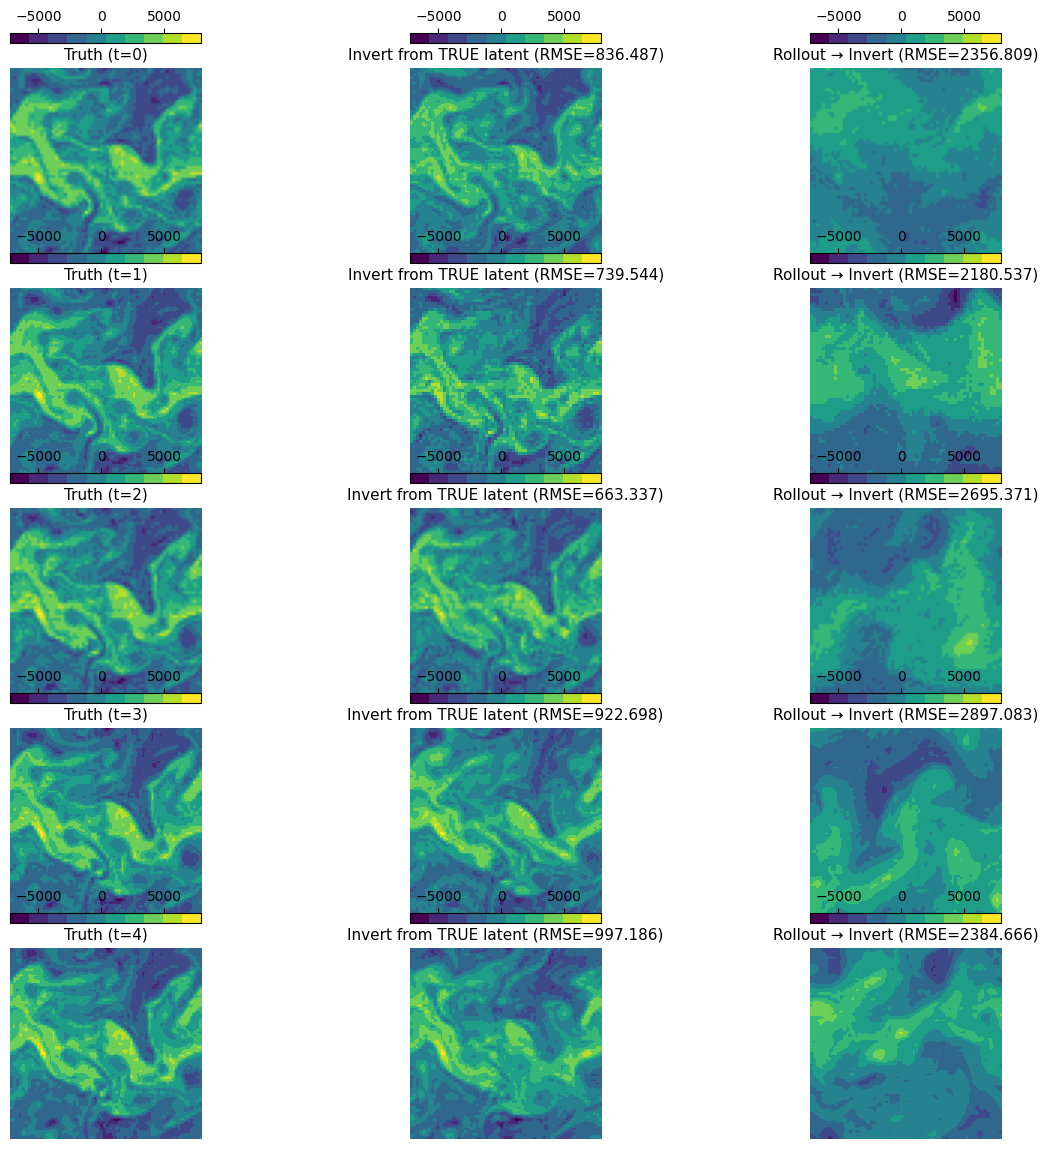

In [20]:
visualize_truth_invert_rollout()

AR(2)模型的拟合尝试（这个尝试已经完全失去了一些理论依据的支持）

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------
# 1) Fit AR(2) per-dimension
# -----------------------------
def fit_ar2_diagonal_from_trajs(noise_traj):
    """
    Fit AR(2) independently for each latent dimension (diagonal AR(2)).
    noise_traj: np.ndarray, shape (T, C, H, W)
    Returns:
      phi1, phi2, sigma2: np.ndarray of shape (D,)
    """
    T, C, H, W = noise_traj.shape
    D = H * W
    # use channel-0 as latent (aligns with your pipeline)
    Z = noise_traj[:, 0, ...].reshape(T, D).astype(np.float32)  # (T, D)

    # Build (y, X) for AR(2): y_t = phi1*z_{t-1} + phi2*z_{t-2} + e_t
    Y    = Z[2:, :]      # (T-2, D)
    Z_t1 = Z[1:-1, :]    # (T-2, D)
    Z_t2 = Z[0:-2, :]    # (T-2, D)

    # Closed-form per-dimension ridge-OLS
    lam = 1e-3
    phi1 = np.zeros(D, dtype=np.float32)
    phi2 = np.zeros(D, dtype=np.float32)
    sigma2 = np.zeros(D, dtype=np.float32)

    # Solve for each column j
    # beta = (X^T X + lam I)^{-1} X^T y, where X=[z_{t-1}, z_{t-2}]
    for j in range(D):
        Xj = np.stack([Z_t1[:, j], Z_t2[:, j]], axis=1)   # (T-2, 2)
        yj = Y[:, j]                                      # (T-2,)
        XtX = Xj.T @ Xj + lam * np.eye(2, dtype=np.float32)
        Xty = Xj.T @ yj
        beta = np.linalg.solve(XtX, Xty)                  # (2,)
        phi1[j], phi2[j] = beta[0], beta[1]
        resid = yj - Xj @ beta
        sigma2[j] = max(np.mean(resid**2), 1e-12)
    return phi1, phi2, sigma2


# -----------------------------
# 2) AR(2) rollout in latent
# -----------------------------
def rollout_ar2_latent(z_tm1, z_tm2, phi1, phi2, sigma2=None, T_steps=5, rng=None):
    """
    Deterministic or MC rollout for AR(2) per-dimension.
    z_tm1, z_tm2: np.ndarray (D,)
    phi1, phi2, sigma2: (D,)
    sigma2=None => deterministic (no process noise)
    Returns:
      Z_roll: (T_steps, D)
    """
    if rng is None:
        rng = np.random.default_rng()
    D = z_tm1.size
    Z = np.zeros((T_steps, D), dtype=np.float32)
    Z[0, :] = z_tm2.astype(np.float32)  # time index alignment: we will produce t=0..T_steps-1
    if T_steps >= 2:
        Z[1, :] = z_tm1.astype(np.float32)
    add_noise = sigma2 is not None
    if add_noise:
        sig = np.sqrt(sigma2).astype(np.float32)

    for t in range(2, T_steps):
        mean_next = phi1 * Z[t-1, :] + phi2 * Z[t-2, :]
        if add_noise:
            eps = rng.standard_normal(D).astype(np.float32) * sig
            Z[t, :] = mean_next + eps
        else:
            Z[t, :] = mean_next
    return Z  # (T_steps, D)


# -----------------------------
# 3) Invert latent -> physics
# -----------------------------
def invert_latent_sequence_to_physics(lat_seq, sampler, device, data_std, H, W):
    """
    lat_seq: (T, D)
    Returns physics: (T, H, W) after sampler.sample and de-standardization
    """
    T, D = lat_seq.shape
    x = lat_seq.reshape(T, H, W)[:, None, ...]                  # (T,1,H,W)
    x = np.concatenate([x, np.zeros_like(x)], axis=1)           # (T,2,H,W)
    xt = torch.from_numpy(x).to(torch.float32).to(device)
    phys = sampler.sample(xt).detach().cpu().numpy()[:, 0, ...] # (T,H,W)
    phys = phys * data_std
    return phys


# -----------------------------
# 4) Visualization (3 columns)
# -----------------------------
def _add_top_cbar(im):
    ax = im.axes
    cax = inset_axes(ax, width="100%", height="5%", loc='upper center',
                     bbox_to_anchor=(0, 0.18, 1, 1),
                     bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

def visualize_three_columns(truth_phys, invert_from_true_phys, rollout_phys):
    """
    All are (T, H, W)
    """
    T = truth_phys.shape[0]
    vmin = min(truth_phys.min(), invert_from_true_phys.min(), rollout_phys.min())
    vmax = max(truth_phys.max(), invert_from_true_phys.max(), rollout_phys.max())
    rmse2 = np.sqrt(((invert_from_true_phys - truth_phys) ** 2).mean(axis=(1,2)))
    rmse3 = np.sqrt(((rollout_phys         - truth_phys) ** 2).mean(axis=(1,2)))

    fig, axs = plt.subplots(T, 3, figsize=(12, 2.2 * T), constrained_layout=True)
    axs = np.atleast_2d(axs)
    cmap = plt.get_cmap('viridis', 10)

    for t in range(T):
        ax = axs[t, 0]; ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(truth_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Truth (t={t})"); _add_top_cbar(im)

        ax = axs[t, 1]; ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(invert_from_true_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Invert from TRUE latent (RMSE={rmse2[t]:.3f})"); _add_top_cbar(im)

        ax = axs[t, 2]; ax.set_aspect('equal'); ax.axis('off')
        im = ax.imshow(rollout_phys[t], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Rollout → Invert (RMSE={rmse3[t]:.3f})"); _add_top_cbar(im)
    plt.show()


# -----------------------------
# 5) End-to-end minimal pipeline
# -----------------------------
def ar2_prob_predict_minimal_pipeline(
    truth_traj,         # np.ndarray (T, C, H, W)
    noise_traj,         # np.ndarray (T, C, H, W)  latent input
    sampler,            # callable: sampler.sample(torch.Tensor[T,2,H,W]) -> torch.Tensor[T,2,H,W]
    device,             # torch device
    data_std,           # float, de-standardization factor
    members=5,          # rollout length & frames to visualize
    use_process_noise=False,  # if True, include sigma2 noise
    rng=None
):
    """
    1) Fit AR(2) per-dimension from the whole given 'noise_traj'
    2) Compute 'invert-from-TRUE-latent' on first 'members' frames
    3) Rollout AR(2) from the first two latent frames, map to physics
    4) Visualize 3 columns
    """
    T, C, H, W = truth_traj.shape
    assert noise_traj.shape == truth_traj.shape

    # Fit AR(2) per-dimension
    phi1, phi2, sigma2 = fit_ar2_diagonal_from_trajs(noise_traj)

    # Column-2: invert from true latent for first 'members'
    x_true_lat = torch.from_numpy(noise_traj[:members, ...]).to(torch.float32).to(device)
    phys_from_true = sampler.sample(x_true_lat).detach().cpu().numpy()[:, 0, ...] * data_std  # (members,H,W)

    # Column-1: ground-truth physics (channel-0)
    truth_phys = truth_traj[:members, 0, ...]  # (members,H,W)

    # Column-3: AR(2) rollout → invert
    z_tm2 = noise_traj[0, 0, ...].reshape(-1)   # (D,)
    z_tm1 = noise_traj[1, 0, ...].reshape(-1)   # (D,)
    sig2   = sigma2 if use_process_noise else None
    Z_roll = rollout_ar2_latent(z_tm1, z_tm2, phi1, phi2, sig2, T_steps=members, rng=rng)  # (members,D)
    phys_from_roll = invert_latent_sequence_to_physics(Z_roll, sampler, device, data_std, H, W)

    # Visualize
    visualize_three_columns(truth_phys, phys_from_true, phys_from_roll)

    # Also return RMSEs for logging
    rmse_from_true  = float(np.sqrt(((phys_from_true - truth_phys)**2).mean()))
    rmse_from_roll  = float(np.sqrt(((phys_from_roll - truth_phys)**2).mean()))
    return {
        "phi1_mean": float(np.mean(phi1)),
        "phi2_mean": float(np.mean(phi2)),
        "sigma2_mean": float(np.mean(sigma2)),
        "rmse_invert_from_true": rmse_from_true,
        "rmse_rollout": rmse_from_roll
    }


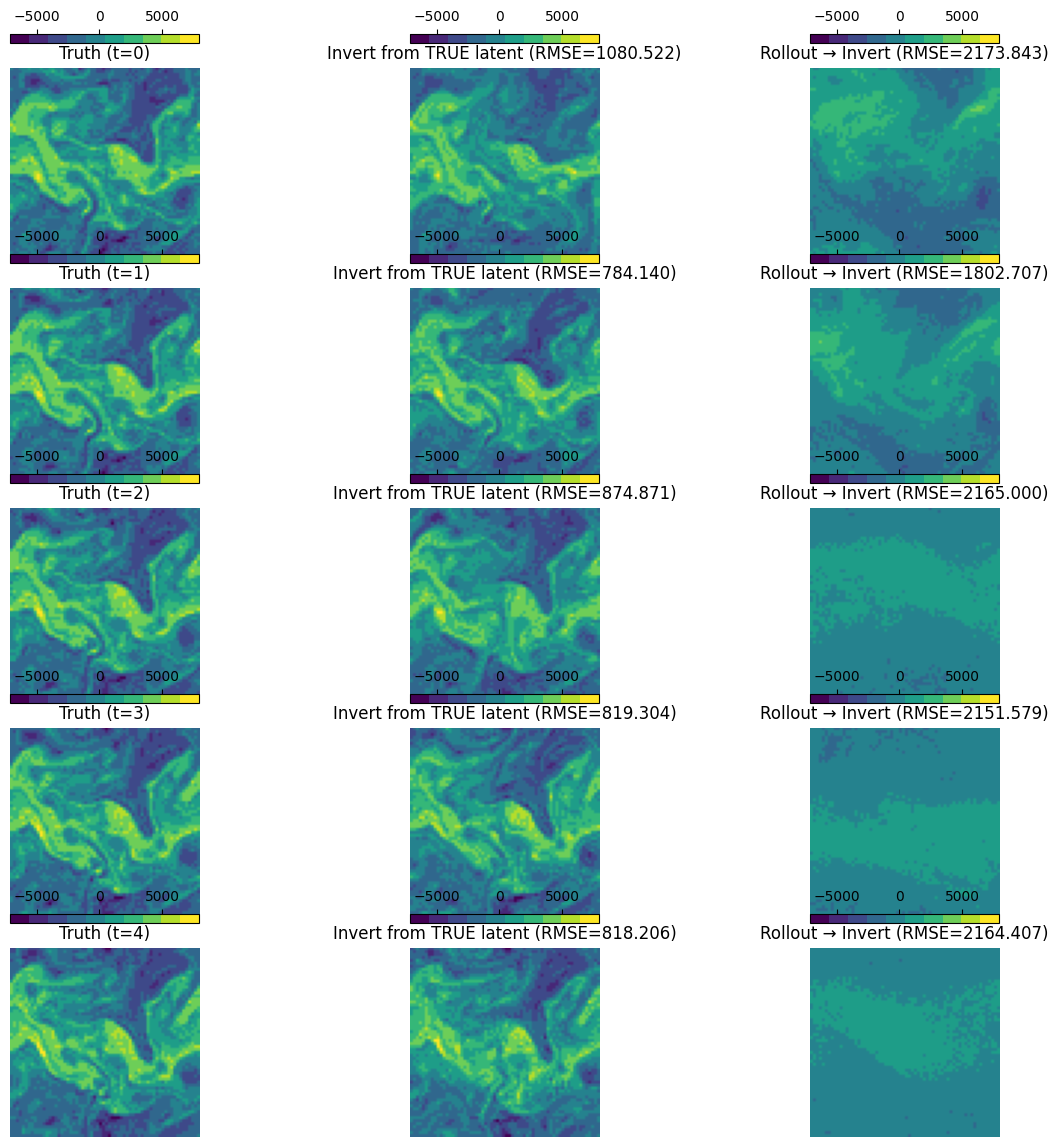

{'phi1_mean': 0.1618174910545349, 'phi2_mean': -0.011393042281270027, 'sigma2_mean': 0.9541276097297668, 'rmse_invert_from_true': 881.8755021685888, 'rmse_rollout': 2096.4980177393318}


In [22]:
# Example (adjust to your environment)
# truth_traj, noise_traj: np.ndarray (T,C,H,W)
# sampler: your sampler object with .sample()
# device: torch.device("cuda:0") or "cpu"
# data_std: e.g., 2660
# members: e.g., 5

truth_traj = new_data.get_traj(traj_id=0, dataset="truth")
noise_traj = new_data.get_traj(traj_id=0, dataset="noise")

stats = ar2_prob_predict_minimal_pipeline(
    truth_traj=truth_traj,
    noise_traj=noise_traj,
    sampler=sampler,
    device=device,
    data_std=2660.0,
    members=5,
    use_process_noise=False  # set True to include process noise
)
print(stats)


In [23]:
np.mean(noise_traj[0, 0])

np.float32(0.008662729)

我们之前做了时序分析，但是用的是ACF(Autocovariance Function)自协方差函数， 从来没有做过跨像素的跨时间的covariance

这个叫Spatio‑temporal geostatistics

我们接下来要做这个分析，然后去确定我们概率预测的模型形式

不做了，后面补一个算了

In [1]:
import sys, os

# 把 Try 的上一级目录（也就是 sampler.py 所在目录）加到 sys.path
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from HMMs import run_lowrank_ou_sigma_comparison

run_lowrank_ou_sigma_comparison(
    rank_A=64,
    rank_sigma=32,
    traj_id=0,
    members=15,
    data_std=2660.0,
)


KeyboardInterrupt: 

结果不太行， space-time covariance的分析还是要做, 做了一个初步的分块的分析，但是这个肯定是用不到建模上面去的，当乐子看好了

------------------------------------------------------
 SQG Trajectory Dataset Loaded
  trajectories = 100
  time steps   = 101
  levels       = 2
  spatial grid = 64 × 64
  shape        = (100, 101, 2, 64, 64)
------------------------------------------------------


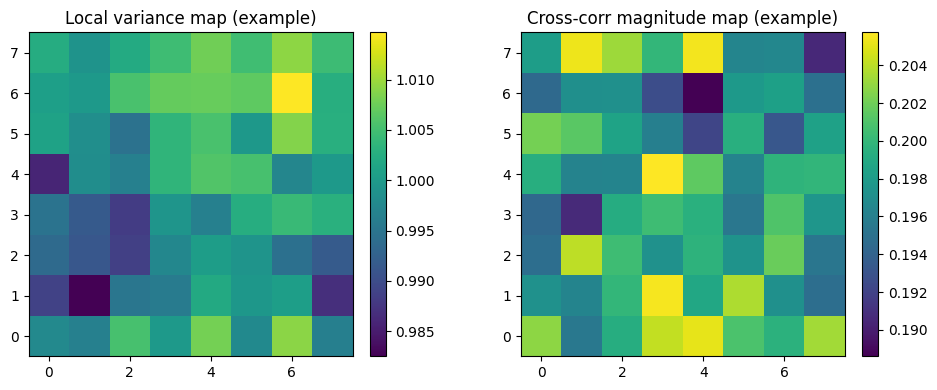

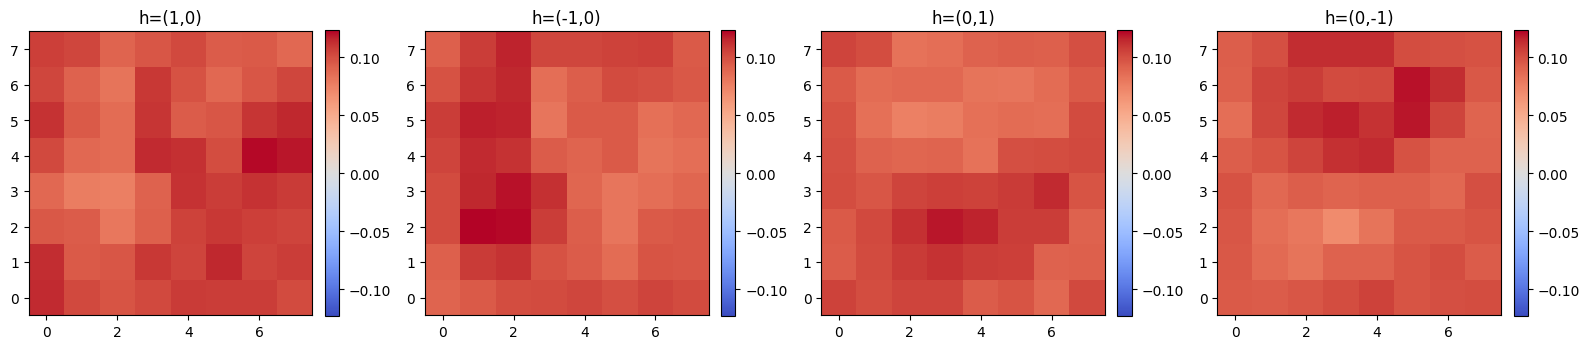

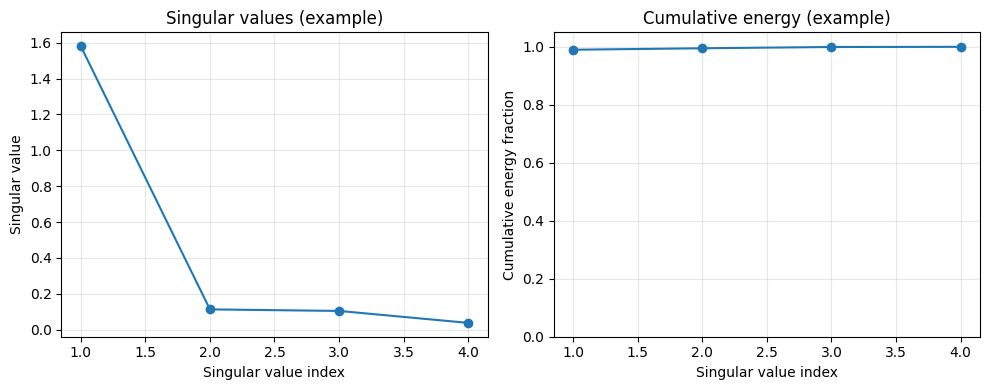

In [2]:
from cross_covariance_anlysis import run_cross_covariance_pipeline

run_cross_covariance_pipeline()

✅ SQG 数据加载完成: shape = (1001, 2, 64, 64), data_std = 2660.0
—— 局部分析小结 ——
分块: (3, 3), 帧数用于平均: 10, 局部标准化: True
ξ（相关长度）范围: [1, 1] px
D（方向离散度）中位数: 0.000（越小越各向同性）
κ（谱椭圆率）范围: [1.04, 1.65]（≈1为圆对称）

=== Summary (AIC/BIC comparisons) ===
[Spectrum]  AIC 1-seg = -130.33, 2-seg = -142.66  --> ΔAIC=12.33
           BIC 1-seg = -126.72, 2-seg = -133.62  --> ΔBIC=6.91
[Radial ACF] AIC 1-scale = -227.78, 2-scale = -213.43 --> ΔAIC=-14.35
   Best 1-scale ell=1.00
   Best 2-scale w=0.95, ell=(1.00,10.00)
[xi-map]     BIC 1G = -227.74, 2G = nan --> ΔBIC=nan
   Fit2: weights=[nan, nan], mu=[nan, nan], var=[nan, nan]


/tmp/ipykernel_3394/1983143549.py:231: RuntimeWarning: divide by zero encountered in scalar divide
  N0 = (1.0/np.sqrt(2*np.pi*var[0])) * np.exp(-0.5*(x-mu[0])**2/var[0])
/tmp/ipykernel_3394/1983143549.py:231: RuntimeWarning: invalid value encountered in divide
  N0 = (1.0/np.sqrt(2*np.pi*var[0])) * np.exp(-0.5*(x-mu[0])**2/var[0])


{'spectrum': {'ok': True,
  'aic_1seg': np.float64(-130.3293188806074),
  'bic_1seg': np.float64(-126.71599390106675),
  'rss_1seg': 2.2740593961033806,
  'aic_2seg': np.float64(-142.65582051830535),
  'bic_2seg': np.float64(-133.62250806945374),
  'rss_2seg': 1.5133275816360006,
  'break_index': 9,
  'x': array([1.00000008e-09, 6.93147181e-01, 1.09861229e+00, 1.38629436e+00,
         1.60943791e+00, 1.79175947e+00, 1.94591015e+00, 2.07944154e+00,
         2.19722458e+00, 2.30258509e+00, 2.39789527e+00, 2.48490665e+00,
         2.56494936e+00, 2.63905733e+00, 2.70805020e+00, 2.77258872e+00,
         2.83321334e+00, 2.89037176e+00, 2.94443898e+00, 2.99573227e+00,
         3.04452244e+00, 3.09104245e+00, 3.13549422e+00, 3.17805383e+00,
         3.21887582e+00, 3.25809654e+00, 3.29583687e+00, 3.33220451e+00,
         3.36729583e+00, 3.40119738e+00, 3.43398720e+00, 3.46573590e+00,
         3.49650756e+00, 3.52636052e+00, 3.55534806e+00, 3.58351894e+00,
         3.61091791e+00, 3.63758616e+

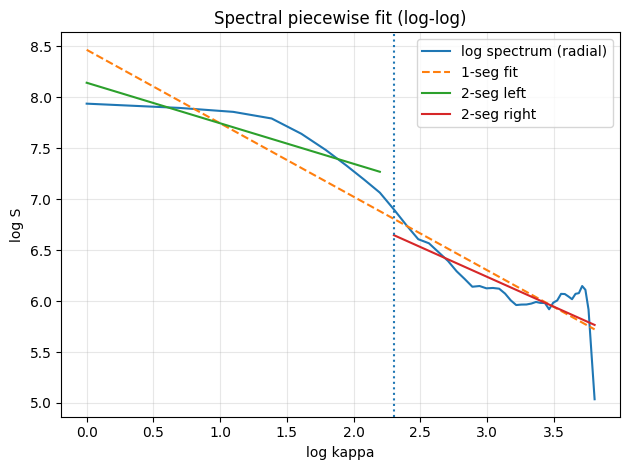

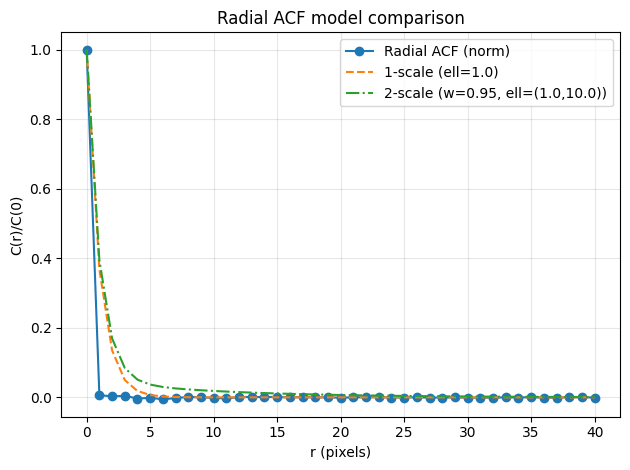

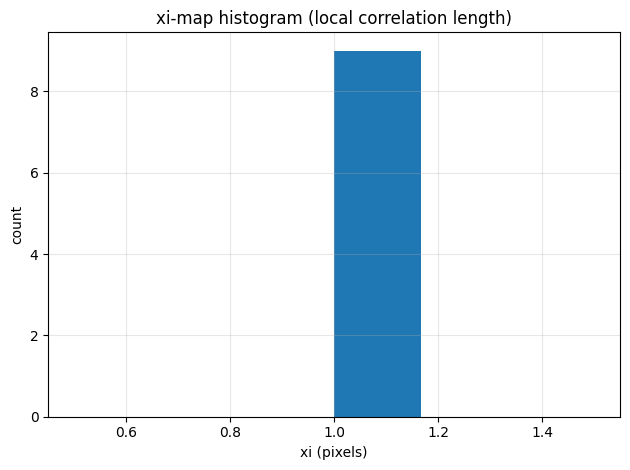

In [10]:
# -*- coding: utf-8 -*-
# Multi-scale diagnostics runner
# This script reuses your existing helpers and wraps them into callable functions.
# It produces four lines of evidence:
#   A) Spectral (power spectrum) piecewise log-log fit: 1-seg vs 2-seg
#   B) Radial ACF model comparison: single-scale vs two-scale exponential
#   C) Local correlation length (xi) multimodality: 1-Gaussian vs 2-Gaussian (EM + BIC)
#   D) Nonlinear correlation (HSIC) per-block "knee"/length distribution
#
# Notes:
# - All plots use matplotlib (no seaborn).
# - New code is encapsulated as functions as requested.
#
import sys, os, math, numpy as np
import matplotlib.pyplot as plt

# Ensure local module path
if "/mnt/data" not in sys.path:
    sys.path.append("/mnt/data")

# Import from your files
from data import SQGData, SQGTrajData
# spatial_correlation.py implements the diagnostics we need
# nonlinear_temporal... file defines HSIC tools we will reuse
import spatial_correlation as SC
import nonlinear_temporal_correlation_detection as NL  # contains HSIC tools in your uploaded file

# -------------------------
# Utilities (local helpers)
# -------------------------
def _radial_average_numpy(img2d):
    """Compute radial average of a 2D array around its center (integer center)."""
    H, W = img2d.shape
    cy, cx = H//2, W//2
    yy, xx = np.indices((H, W))
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2).astype(np.int64)
    rmax = r.max()
    sums = np.bincount(r.ravel(), weights=img2d.ravel(), minlength=rmax+1)
    cnts = np.bincount(r.ravel(), minlength=rmax+1).astype(np.float64)
    cnts[cnts == 0] = 1.0
    return sums / cnts

def _aic(n, rss, k):
    """AIC for least squares fit: n*log(RSS/n) + 2k (constant dropped)."""
    rss = max(rss, 1e-12)
    return n*np.log(rss/n) + 2*k

def _bic(n, rss, k):
    """BIC for least squares fit: n*log(RSS/n) + k*log(n) (constant dropped)."""
    rss = max(rss, 1e-12)
    return n*np.log(rss/n) + k*np.log(n)

# ---------------------------------------------
# A) Spectral piecewise fit on radial spectrum
# ---------------------------------------------
def spectral_piecewise_test(field, average_frames=10, smooth_sigma=1.5, min_seg_len=6):
    """
    Reuse spatial_correlation_diagnostics() to get periodogram, then do
    1-seg vs 2-seg line fits on log S vs log kappa (radial spectrum).
    Returns a dict with AIC/BIC comparison and break location.
    """
    res = SC.spatial_correlation_diagnostics(field,
                                             average_frames=average_frames,
                                             show_plots=False,
                                             thresholds=dict(mu_abs_max=1e9, std_ratio_max=1e9,
                                                             delta_median_max=1e9, D_median_max=1e9,
                                                             kappa_max=1e9))
    S = res["periodogram_smooth"]  # smoothed spectrum
    radial = _radial_average_numpy(S)
    # remove r=0 and zero/negatives for log
    r = np.arange(len(radial))[1:]
    y = radial[1:]
    mask = np.isfinite(y) & (y > 0)
    r = r[mask]
    y = y[mask]
    if len(y) < 2*min_seg_len + 1:
        return {"ok": False, "reason": "Not enough spectral bins for piecewise fit."}

    x = np.log(r + 1e-9)
    z = np.log(y)

    # 1-segment: z = a + b*x
    X1 = np.vstack([np.ones_like(x), x]).T
    beta1, *_ = np.linalg.lstsq(X1, z, rcond=None)
    z1 = X1 @ beta1
    rss1 = float(np.sum((z - z1)**2))
    aic1 = _aic(len(z), rss1, k=2)
    bic1 = _bic(len(z), rss1, k=2)

    # 2-segment: choose breakpoint via grid, enforce min_seg_len
    best = {"aic": np.inf}
    for bp in range(min_seg_len, len(x)-min_seg_len):
        xL, zL = x[:bp], z[:bp]
        xR, zR = x[bp:], z[bp:]
        Xl = np.vstack([np.ones_like(xL), xL]).T
        Xr = np.vstack([np.ones_like(xR), xR]).T
        bl, *_ = np.linalg.lstsq(Xl, zL, rcond=None)
        br, *_ = np.linalg.lstsq(Xr, zR, rcond=None)
        zl = Xl @ bl
        zr = Xr @ br
        rss = float(np.sum((zL - zl)**2) + np.sum((zR - zr)**2))
        k = 4 + 1  # 2 params per segment + 1 breakpoint
        aic = _aic(len(z), rss, k=k)
        bic = _bic(len(z), rss, k=k)
        if aic < best["aic"]:
            best = {"aic": aic, "bic": bic, "rss": rss, "bp": bp, "bl": bl, "br": br}

    out = {
        "ok": True,
        "aic_1seg": aic1, "bic_1seg": bic1, "rss_1seg": rss1,
        "aic_2seg": best["aic"], "bic_2seg": best["bic"], "rss_2seg": best["rss"],
        "break_index": int(best["bp"]), "x": x, "z": z, "beta1": beta1, "best": best,
        "radial_spectrum": radial
    }

    # Plot
    plt.figure()
    plt.plot(x, z, label="log spectrum (radial)")
    # 1-seg
    plt.plot(x, z1, linestyle="--", label="1-seg fit")
    # 2-seg
    bp = best["bp"]
    xL, xR = x[:bp], x[bp:]
    zL_fit = np.vstack([np.ones_like(xL), xL]).T @ best["bl"]
    zR_fit = np.vstack([np.ones_like(xR), xR]).T @ best["br"]
    plt.plot(xL, zL_fit, label="2-seg left")
    plt.plot(xR, zR_fit, label="2-seg right")
    plt.axvline(x[bp], linestyle=":")
    plt.title("Spectral piecewise fit (log-log)")
    plt.xlabel("log kappa"); plt.ylabel("log S")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    return out

# ---------------------------------------------
# B) Radial ACF single vs two-scale fits
# ---------------------------------------------
def _exp1(r, sig2, ell):
    return sig2 * np.exp(-r / max(ell, 1e-9))

def _exp2(r, sig2, w, ell1, ell2):
    # 0<=w<=1
    w = min(max(w, 0.0), 1.0)
    return sig2 * (w*np.exp(-r/max(ell1,1e-9)) + (1-w)*np.exp(-r/max(ell2,1e-9)))

def acf_model_compare(field, average_frames=10, r_max=None):
    """
    Compare single-scale vs two-scale exponential on radial ACF.
    Coarse grid search for robustness (no SciPy dependency).
    """
    res = SC.spatial_correlation_diagnostics(field,
                                             average_frames=average_frames,
                                             show_plots=False,
                                             thresholds=dict(mu_abs_max=1e9, std_ratio_max=1e9,
                                                             delta_median_max=1e9, D_median_max=1e9,
                                                             kappa_max=1e9))
    radial = res["radial_correlation"]  # C(r)
    r = np.arange(len(radial))
    if r_max is None:
        r_max = min(len(r)-1, 40)
    r = r[:r_max+1]
    c = radial[:r_max+1]
    # normalize to C(0)=1 for fitting stability
    if c[0] == 0:
        return {"ok": False, "reason": "Radial ACF has zero at r=0."}
    c = c / c[0]

    n = len(r)

    # 1-scale grid over ell
    ell_grid = np.linspace(1.0, max(3.0, r_max), 60)
    best1 = {"rss": np.inf}
    sig2 = 1.0  # after normalization
    for ell in ell_grid:
        y = _exp1(r, sig2, ell)
        rss = float(np.sum((c - y)**2))
        if rss < best1["rss"]:
            best1 = {"rss": rss, "ell": float(ell)}
    aic1 = _aic(n, best1["rss"], k=1)  # parameters: ell (sig2 fixed=1)

    # 2-scale grid over (w, ell1, ell2), ell1<ell2 enforced by grid
    w_grid = np.linspace(0.05, 0.95, 10)
    ell_small = np.linspace(1.0, max(2.0, r_max/3), 20)
    ell_large = np.linspace(max(2.5, r_max/4), max(3.0, r_max), 20)
    best2 = {"rss": np.inf}
    for w in w_grid:
        for e1 in ell_small:
            for e2 in ell_large:
                if e2 <= e1:
                    continue
                y = _exp2(r, sig2, w, e1, e2)
                rss = float(np.sum((c - y)**2))
                if rss < best2["rss"]:
                    best2 = {"rss": rss, "w": float(w), "ell1": float(e1), "ell2": float(e2)}
    aic2 = _aic(n, best2["rss"], k=3)  # (w, ell1, ell2)

    # Plot fits
    plt.figure()
    plt.plot(r, c, marker="o", label="Radial ACF (norm)")
    y1 = _exp1(r, 1.0, best1["ell"])
    y2 = _exp2(r, 1.0, best2["w"], best2["ell1"], best2["ell2"])
    plt.plot(r, y1, linestyle="--", label=f"1-scale (ell={best1['ell']:.1f})")
    plt.plot(r, y2, linestyle="-.", label=f"2-scale (w={best2['w']:.2f}, ell=({best2['ell1']:.1f},{best2['ell2']:.1f}))")
    plt.title("Radial ACF model comparison")
    plt.xlabel("r (pixels)"); plt.ylabel("C(r)/C(0)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()

    return {"ok": True, "aic_1": aic1, "aic_2": aic2, "best1": best1, "best2": best2,
            "r": r, "c": c}

# ------------------------------------------------------
# C) xi-map multimodality via 1G vs 2G Gaussian (EM+BIC)
# ------------------------------------------------------
def _fit_gaussian_1(x):
    mu = float(np.mean(x))
    var = float(np.var(x) + 1e-12)
    ll = float(np.sum(-0.5*np.log(2*np.pi*var) - 0.5*(x-mu)**2/var))
    k = 2  # mu, var
    return {"mu":[mu], "var":[var], "weight":[1.0], "ll": ll, "k": k}

def _em_gaussian_2(x, max_iter=200, tol=1e-6):
    # init via two-quantile split
    x = x.reshape(-1, 1)
    n = len(x)
    q = np.quantile(x, [0.33, 0.66]).ravel()
    mu = np.array([q[0], q[1]], dtype=float).reshape(2,1)
    var = np.array([np.var(x), np.var(x)/2 + 1e-6], dtype=float)
    pi = np.array([0.5, 0.5], dtype=float)
    for _ in range(max_iter):
        # E-step
        # responsibility r_{ik} ∝ pi_k N(x_i|mu_k, var_k)
        N0 = (1.0/np.sqrt(2*np.pi*var[0])) * np.exp(-0.5*(x-mu[0])**2/var[0])
        N1 = (1.0/np.sqrt(2*np.pi*var[1])) * np.exp(-0.5*(x-mu[1])**2/var[1])
        num0 = pi[0]*N0
        num1 = pi[1]*N1
        den = num0 + num1 + 1e-18
        r0 = num0/den
        r1 = num1/den
        # M-step
        Nk0 = float(np.sum(r0)); Nk1 = float(np.sum(r1))
        pi = np.array([Nk0/n, Nk1/n])
        mu0 = float(np.sum(r0*x)/Nk0); mu1 = float(np.sum(r1*x)/Nk1)
        var0 = float(np.sum(r0*(x-mu0)**2)/Nk0 + 1e-12)
        var1 = float(np.sum(r1*(x-mu1)**2)/Nk1 + 1e-12)
        delta = abs(mu0-mu[0]) + abs(mu1-mu[1])
        mu = np.array([mu0, mu1], dtype=float).reshape(2,1)
        var = np.array([var0, var1], dtype=float)
        if delta < tol:
            break
    # loglik
    N0 = (1.0/np.sqrt(2*np.pi*var[0])) * np.exp(-0.5*(x-mu[0])**2/var[0])
    N1 = (1.0/np.sqrt(2*np.pi*var[1])) * np.exp(-0.5*(x-mu[1])**2/var[1])
    ll = float(np.sum(np.log(pi[0]*N0 + pi[1]*N1 + 1e-18)))
    k = 5  # pi (1 free), mu2, var2 -> total parameters = 5
    return {"mu": mu.ravel().tolist(), "var": var.tolist(), "weight": pi.tolist(), "ll": ll, "k": k}

def xi_multimodality_test(field, average_frames=10, blocks=(3,3)):
    """
    Use spatial_correlation_local_report() to compute xi-map and then test 1-Gaussian vs 2-Gaussian.
    Report BIC difference and plot histogram with component means.
    """
    res = SC.spatial_correlation_local_report(field,
                                              average_frames=average_frames,
                                              blocks=blocks,
                                              use_local_standardize=True,
                                              show_plots=False)
    xi = res["xi_map"].ravel()
    xi = xi[np.isfinite(xi)]
    xi = xi.astype(np.float64)
    if xi.size < 6:
        return {"ok": False, "reason": "Too few xi samples."}

    fit1 = _fit_gaussian_1(xi)
    fit2 = _em_gaussian_2(xi)
    n = len(xi)
    bic1 = -2*fit1["ll"] + fit1["k"]*np.log(n)
    bic2 = -2*fit2["ll"] + fit2["k"]*np.log(n)

    # plot histogram + component means
    plt.figure()
    plt.hist(xi, bins=min(20, max(6, len(xi)//2)))
    for m in fit2["mu"]:
        plt.axvline(m, linestyle="--")
    plt.title("xi-map histogram (local correlation length)")
    plt.xlabel("xi (pixels)"); plt.ylabel("count")
    plt.grid(True, alpha=0.3); plt.tight_layout()

    return {"ok": True, "bic_1G": float(bic1), "bic_2G": float(bic2),
            "fit1": fit1, "fit2": fit2, "xi": xi, "blocks": blocks}

# ------------------------------------------------------
# D) HSIC per-block radial curves + knee distribution
# ------------------------------------------------------
def hsic_block_knee_test(field, blocks=(2,2), average_frames=10, max_shift=15):
    """
    Use your hsic_blockwise() to get per-block radial curves, then derive a
    'nonlinear correlation length' xi_nl via provided helper, and check dispersion.
    """
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    field_t = torch.as_tensor(field, dtype=torch.float64, device=device)

    results = NL.hsic_blockwise(
        field_t,
        blocks=blocks,
        max_shift=max_shift,
        average_frames=average_frames,
        radial=True,
        max_samples=3000,
        spatial_stride=2,
        device=device,
        per_frame_standardize=True,
        show_progress=False
    )
    xis = []
    radials = []
    labels = []
    for blk in results["per_block"]:
        radials.append(blk["radial"])
        labels.append(str(blk["block_index"]))
        xi = NL.nonlinear_corr_length_from_hsic(blk["radial"])
        xis.append(float(xi) if xi is not None else np.nan)
    xis = np.array(xis, dtype=np.float64)

    # Plot all radial curves normalized by first-band mean
    NL.plot_hsic_radials(radials, labels=labels, normalize="first_band", smooth=5)
    plt.title("HSIC radial curves per block")
    plt.tight_layout()

    # Plot xi_nl distribution
    plt.figure()
    finite = xis[np.isfinite(xis)]
    if finite.size > 0:
        plt.hist(finite, bins=min(12, max(4, len(finite)//2)))
    plt.title("Nonlinear correlation length (xi_nl) across blocks")
    plt.xlabel("xi_nl (pixels)"); plt.ylabel("count")
    plt.grid(True, alpha=0.3); plt.tight_layout()

    return {"ok": True, "xi_nl": xis, "radials": radials, "labels": labels, "blocks": blocks}

# --------------------
# Runner (example use)
# --------------------
def run_all_diagnostics():
    # Load field (same as your examples)
    sqg = SQGData()
    field = sqg.get_field()  # (T, H, W)

    # A) spectrum piecewise
    spec = spectral_piecewise_test(field, average_frames=10)

    # B) ACF model compare
    acf = acf_model_compare(field, average_frames=10)

    # C) xi-map multimodality
    xi = xi_multimodality_test(field, average_frames=10, blocks=(3,3))

    # D) HSIC block-knee
    # hsic = hsic_block_knee_test(field, blocks=(2,2), average_frames=10, max_shift=15)

    print("\n=== Summary (AIC/BIC comparisons) ===")
    if spec["ok"]:
        print(f"[Spectrum]  AIC 1-seg = {spec['aic_1seg']:.2f}, 2-seg = {spec['aic_2seg']:.2f}  --> ΔAIC={spec['aic_1seg']-spec['aic_2seg']:.2f}")
        print(f"           BIC 1-seg = {spec['bic_1seg']:.2f}, 2-seg = {spec['bic_2seg']:.2f}  --> ΔBIC={spec['bic_1seg']-spec['bic_2seg']:.2f}")
    if acf["ok"]:
        print(f"[Radial ACF] AIC 1-scale = {acf['aic_1']:.2f}, 2-scale = {acf['aic_2']:.2f} --> ΔAIC={acf['aic_1']-acf['aic_2']:.2f}")
        print(f"   Best 1-scale ell={acf['best1']['ell']:.2f}")
        print(f"   Best 2-scale w={acf['best2']['w']:.2f}, ell=({acf['best2']['ell1']:.2f},{acf['best2']['ell2']:.2f})")
    if xi["ok"]:
        print(f"[xi-map]     BIC 1G = {xi['bic_1G']:.2f}, 2G = {xi['bic_2G']:.2f} --> ΔBIC={xi['bic_1G']-xi['bic_2G']:.2f}")
        print(f"   Fit2: weights={xi['fit2']['weight']}, mu={xi['fit2']['mu']}, var={xi['fit2']['var']}")

    return {"spectrum": spec, "acf": acf, "xi": xi}

# Execute
results = run_all_diagnostics()
results
